In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [2]:
import pandas as pd
import numpy as np
from scipy.spatial import distance_matrix
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import plotly.graph_objects as go
import plotly.colors as pc
from datetime import datetime
from scipy.spatial.distance import cdist
import math
import time
import os
import sys


torch.manual_seed(42)
np.random.seed(42)

print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0)) 

torch.set_float32_matmul_precision('high')

True
12.8
Tesla T4


In [3]:
sequences = pd.read_csv('/kaggle/input/datasets/timpi4ever/rna-folding/data/train_sequences.v2.csv')

In [4]:
labels = pd.read_csv('/kaggle/input/datasets/timpi4ever/rna-folding/data/train_labels.v2.csv')

In [5]:
test_sequences = pd.read_csv('/kaggle/input/datasets/timpi4ever/rna-folding/data/validation_sequences.csv')

In [6]:
test_set = pd.read_csv('/kaggle/input/datasets/timpi4ever/rna-folding/data/validation_labels.csv')

In [7]:
def strip_suffix(x: str) -> str:
    if '_' in x:
        return '_'.join(x.split('_')[:-1])
    
    return x

In [8]:
def plot_points(points: pd.DataFrame, ax, title: str="", tm_score_val: float=0, limit: bool=False):    
    unique_ids = points['id'].unique()
    base_maps = ['Reds', 'Blues', 'Greens', 'Oranges', 'Purples', 'Greys']

    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z', labelpad=-1)

    legend_handles = []

    for i, pid in enumerate(unique_ids):
        subset = points[points['id'] == pid]
        cmap = plt.get_cmap(base_maps[i % len(base_maps)])
        ax.scatter(subset['x'], subset['y'], subset['z'], cmap=cmap, c=subset['x'] + subset['y'] + subset['z'], s=8)

        handle = Line2D(
            [0], [0], marker='o', color='w',
            markerfacecolor=cmap(0.6),
            markersize=8, label=pid
        )
        
        legend_handles.append(handle)

    ax.legend(handles=legend_handles, loc='lower left', fontsize=8)

    if limit:
        ax.set_xlim(-15, 15)
        ax.set_ylim(-15, 15)
        ax.set_zlim(-15, 15)

    ax.text2D(
        0.05, 
        0.95, 
        f'TM-score: {tm_score_val:.4f}', 
        transform=ax.transAxes,
        fontsize=9, 
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
    )

In [9]:
def get_rna_points(df: pd.DataFrame, id: str, coord_suffix='1') -> pd.DataFrame:
    points = []

    for _, row in df[df['ID'].str.contains(id, na=False)].iterrows():
        points.append((id, row['x_' + coord_suffix], row['y_' + coord_suffix], row['z_' + coord_suffix]))

    return pd.DataFrame(points, columns=['id', 'x', 'y', 'z'])

In [10]:
labels['target_id'] = labels['ID'].map(strip_suffix)

In [11]:
l = sequences['sequence'].str.len()
s = sequences[l <= 1024]

In [12]:
df = labels[labels['target_id'].isin(s['target_id'])]

In [13]:
MAPPING = {'A': 0, 'G': 1, 'C': 2, 'U': 3}

def encode_sequence(str_seq: pd.Series) -> np.ndarray:
    return str_seq.map(MAPPING).to_numpy(dtype=np.uint8)

def get_coordinates(coordinates: pd.DataFrame, scale: float, t: float = 0) -> np.ndarray:
    coord_values = coordinates[['x', 'y', 'z']].values
    coord_values = coord_values - np.mean(coord_values, axis=0)
    coord_values = (coord_values / scale).astype(np.float32)

    noise = np.random.randn(*coord_values.shape)
    coord_values = np.sqrt(1 - t) * coord_values + np.sqrt(t) * noise

    return coord_values.astype(np.float32)

def get_distance_std_dev(sequence: pd.DataFrame):
    coords = sequence[['x', 'y', 'z']].values
    dist_map = cdist(coords, coords).astype(np.float32)
    mask = ~np.eye(len(coords), dtype=bool)
    
    return dist_map[mask].std() + 1e-6

def get_output_tensor(coordinates: pd.DataFrame) -> np.ndarray:
    coord_values = coordinates[['x', 'y', 'z']].values
    position_distances = distance_matrix(coord_values, coord_values)

    return position_distances[np.newaxis, :, :].astype(np.float32)

def unstack_sequences(sequences: pd.DataFrame):
    result = sequences.copy()
    result = result.set_index(['ID', 'resname', 'resid'])

    result.columns = pd.MultiIndex.from_tuples(
        [tuple(col.split('_')) for col in result.columns],
        names=['', 'idx']
    )

    result = result.stack('idx', future_stack=True).reset_index()
    result = result.replace(-1e18, np.nan)
    result = result.dropna(subset=['x', 'y', 'z'])
    result['target_id'] = result['ID'].map(strip_suffix) + "_" + result['idx']
    result.drop(columns=['idx', 'ID'], inplace=True)
    result = result.reset_index(drop=True)

    return result[['target_id', 'resname', 'resid', 'x', 'y', 'z']]

In [14]:
duplicate_sequences = test_sequences.merge(sequences, on='sequence', suffixes=('_test', '_train'))

In [15]:
df = df[
    ~df['target_id'].isin(duplicate_sequences['target_id_train'])
]

sequences = sequences[
    ~sequences['sequence'].isin(test_sequences['sequence'])
]

In [16]:
X = unstack_sequences(df)

In [17]:
invalid =  X[(X['resname'] != 'A') & (X['resname'] != 'U') & (X['resname'] != 'G') & (X['resname'] != 'C')]['target_id'].unique()

In [18]:
for invalid_sequence in invalid:
    X = X[X['target_id'] != invalid_sequence]

In [19]:
def distances_to_coords(distances: np.ndarray) -> tuple[np.ndarray, float]:
    n = distances.shape[0]

    j = np.eye(n) - np.ones((n, n)) / n

    b = -0.5 * j @ (distances ** 2) @ j

    eigvals, eigvecs = np.linalg.eigh(b)

    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    v = eigvecs[:, :3]
    l = np.diag(np.sqrt(np.maximum(eigvals[:3], 0)))

    coords = v @ l

    neg_mass: float = np.sum(np.abs(eigvals[eigvals < 0]))
    pos_mass: float = np.sum(eigvals[eigvals > 0])

    invalidity_score = neg_mass / (pos_mass + 1e-12)

    return coords, invalidity_score

def align_points(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    centroid_a = a.mean(axis=0)
    centroid_b = b.mean(axis=0)

    aa = a - centroid_a
    bb = b - centroid_b

    h = aa.T @ bb

    u, _, vt = np.linalg.svd(h)

    r = vt.T @ u.T

    if np.linalg.det(r) < 0:
        vt[-1, :] *= -1
        r = vt.T @ u.T

    b_aligned = (bb @ r) + centroid_a
    
    return b_aligned

def d0_scaling(l):
    if l >= 30:
        return 0.6 * np.sqrt(l - 0.5) - 2.5
    
    bins = [
        (12, 0.3),
        (16, 0.4),
        (20, 0.5),
        (24, 0.6),
        (30, 0.7),
    ]
    
    for threshold, val in bins:
        if l < threshold:
            return val
        
def tm_score(a: np.ndarray, b: np.ndarray) -> float:
    b_aligned = align_points(a, b)

    l_ref = len(a)
    d0 = d0_scaling(l_ref)

    dists = np.linalg.norm(a - b_aligned, axis=1)

    return np.sum(1 / (1 + (dists / d0)**2)) / l_ref

In [20]:
class RNADataset(Dataset):
    def __init__(self, df, presample: bool, min_t: float, max_t: float):
        self.samples = [group.copy() for _, group in df.groupby('target_id')]
        self.ts = None
        self.min_t = min_t
        self.max_t = max_t

        if presample:
            self.ts = [self._sample_t() for _ in range(len(self.samples))]

        self.std_devs = []

        for sequence in self.samples:
            self.std_devs.append(float(get_distance_std_dev(sequence)))

    def _sample_t(self):
        raw_t = torch.distributions.Beta(2, 1).sample()
        
        return self.min_t + (raw_t * (self.max_t - self.min_t))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sequence = self.samples[idx]

        t = self.ts[idx] if self.ts else self._sample_t()
        
        std_dev = self.std_devs[idx]
        X = get_coordinates(sequence, std_dev, float(t))
        S = encode_sequence(sequence['resname'])
        Y = get_output_tensor(sequence)

        return X, S, t, Y, std_dev

In [21]:
class ResBlock(nn.Module):
    def __init__(self, channels, kernel_size=3, dilation=1):
        super().__init__()

        self.conv1 = nn.Conv2d(channels, channels, kernel_size, padding='same', dilation=dilation)
        self.norm1 = nn.GroupNorm(8, channels)
        self.act1  = nn.SiLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size, padding='same', dilation=dilation)
        self.norm2 = nn.GroupNorm(8, channels)
        self.act2  = nn.SiLU(inplace=True)

    def forward(self, x):
        residual = x
        
        x = self.conv1(x)
        x = self.norm1(x)
        x = self.act1(x)
        x = self.conv2(x)
        x = self.norm2(x)

        return self.act2(x + residual)

In [22]:
class SinusoidalEncoding(nn.Module):
    def __init__(self, embedding_dim: int):
        super().__init__()

        self.embedding_dim = embedding_dim

    def forward(self, x):
        device = x.device
        half_dim = self.embedding_dim // 2
        
        freqs = torch.exp(
            -torch.arange(0, half_dim, device=device) * (math.log(10000.0) / (half_dim - 1))
        )
        
        args = x.unsqueeze(-1) * freqs
        
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

In [23]:
class RNAConvModel(nn.Module):
    def __init__(
            self,  
            hidden_size, 
            n_nucleotides,
            distance_channels, 
            relational_embedding_length,
            position_encoding_length, 
            time_encoding_length, 
    ):
        super().__init__()

        self.n_nucleotides = n_nucleotides
        self.pair_embedding = nn.Embedding(n_nucleotides**2, relational_embedding_length)
        self.time_encoding = SinusoidalEncoding(time_encoding_length)
        self.position_encoding = SinusoidalEncoding(position_encoding_length)

        input_channels = distance_channels + relational_embedding_length + position_encoding_length + time_encoding_length
        
        self.stem = nn.Sequential(
            nn.Conv2d(input_channels, hidden_size, kernel_size=1),
            nn.GroupNorm(8, hidden_size),
            nn.SiLU(inplace=True),
        )

        self.res1 = ResBlock(hidden_size, dilation=1)
        self.res2 = ResBlock(hidden_size, dilation=2)
        self.res3 = ResBlock(hidden_size, dilation=4)
        self.res4 = ResBlock(hidden_size, dilation=8)
        self.res5 = ResBlock(hidden_size, dilation=16)
        self.res6 = ResBlock(hidden_size, dilation=32)

        self.res7 = ResBlock(hidden_size, dilation=1)
        self.res8 = ResBlock(hidden_size, dilation=2)
        self.res9 = ResBlock(hidden_size, dilation=4)
        self.res10 = ResBlock(hidden_size, dilation=8)
        self.res11 = ResBlock(hidden_size, dilation=16)
        self.res12 = ResBlock(hidden_size, dilation=32)

        self.head = nn.Sequential(
            nn.Conv2d(hidden_size, 1, kernel_size=1),
            nn.Softplus(),
        )

    def forward(self, coords, sequence, t):
        b, n, _ = coords.shape
        device = coords.device

        dist_3d = torch.cdist(coords, coords, p=2).unsqueeze(1)

        pos = torch.arange(n, device=device).float()
        dist_seq = torch.abs(pos.unsqueeze(1) - pos.unsqueeze(0)).unsqueeze(0).expand(b, -1, -1)
        pos_enc = self.position_encoding(dist_seq).permute(0, 3, 1, 2)

        t_enc = self.time_encoding(t).view(b, -1, 1, 1).expand(-1, -1, n, n)

        pair_indices = (sequence.unsqueeze(2) * self.n_nucleotides + sequence.unsqueeze(1)).long()
        pairwise_emb = self.pair_embedding(pair_indices).permute(0, 3, 1, 2)

        x = torch.cat([dist_3d, pos_enc, pairwise_emb, t_enc], dim=1)

        del coords, sequence, dist_3d, pos, dist_seq, pos_enc, t_enc, pair_indices, pairwise_emb

        x = self.stem(x)

        def group_1(h):
            h = self.res1(h)
            h = self.res2(h)

            return self.res3(h)
        
        def group_2(h):
            h = self.res4(h)
            h = self.res5(h)

            return self.res6(h)
        
        def group_3(h):
            h = self.res7(h)
            h = self.res8(h)

            return self.res9(h)
        
        def group_4(h):
            h = self.res10(h)
            h = self.res11(h)

            return self.res12(h)
        
        x = checkpoint(group_1, x, use_reentrant=False)
        x = checkpoint(group_2, x, use_reentrant=False)
        x = checkpoint(group_3, x, use_reentrant=False)
        x = checkpoint(group_4, x, use_reentrant=False)

        x = self.head(x)
        
        x = torch.tril(x, diagonal=-1)

        return x + x.transpose(-1, -2)

distance_channels = 1
hidden_size = 64
n_nucleotides = 4
relational_embedding_length = 8
position_encoding_length = 8
time_encoding_length = 8

model = RNAConvModel(
    hidden_size, 
    n_nucleotides, 
    distance_channels, 
    relational_embedding_length, 
    position_encoding_length, 
    time_encoding_length,
)

device = torch.device('cuda')
model.to(device)

RNAConvModel(
  (pair_embedding): Embedding(16, 8)
  (time_encoding): SinusoidalEncoding()
  (position_encoding): SinusoidalEncoding()
  (stem): Sequential(
    (0): Conv2d(25, 64, kernel_size=(1, 1), stride=(1, 1))
    (1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (2): SiLU(inplace=True)
  )
  (res1): ResBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (act1): SiLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (act2): SiLU(inplace=True)
  )
  (res2): ResBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same, dilation=(2, 2))
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (act1): SiLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same, dilation=(2, 2))
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (ac

In [24]:
train_ids, val_ids = train_test_split(X['target_id'].unique(), test_size=0.1, random_state=42)

train = X[X['target_id'].isin(train_ids)]
val = X[X['target_id'].isin(val_ids)]

train_dataset = RNADataset(train, False, 0, 1)
val_dataset = RNADataset(val, True, 0, 1)

train_loader = DataLoader(
    train_dataset, 
    batch_size=1, 
    shuffle=True, 
    pin_memory=True, 
    num_workers=2, 
    prefetch_factor=4, 
    persistent_workers=True,
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=1, 
    shuffle=False, 
    pin_memory=True, 
    num_workers=2, 
    prefetch_factor=4, 
    persistent_workers=True,
)

In [25]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0, max_run_time=60 * 60 * 24):
        self.end_time = time.time() + max_run_time
        self.max_run_time = max_run_time
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.reason = None
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is not None and score < self.best_score + self.delta:
            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True
                self.reason = "No more improvements"
        else:
            self.best_score = score
            self.best_model_state = model.state_dict()
            self.counter = 0

        if time.time() > self.end_time:
            self.early_stop = True
            self.reason = "Time limit reached"

In [26]:
def create_run_dir(experiment_name: str):
    run_dir = os.path.join('runs', f'{experiment_name}_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}')

    os.makedirs(run_dir, exist_ok=True)

    with open(os.path.join(run_dir, "summary.csv"), 'w') as summary:
        summary.write(
            'Epoch,Learning rate,Average training loss,Average validation loss,Estimated average validation TM-score,Average validation validity score\n',
        )
    
    return run_dir

def run_train_epoch(model, loader, loss_fn, optimizer, scaler):
    print(' ' * 60, end='\r')

    metrics = { 'loss_sum': 0., 'sample_count': 0. }
    model.train()
    
    with torch.enable_grad():
        for i, (x, s, t, y, std_dev) in enumerate(loader, start=1):
            x, s, t, y, std_dev = x.to(device), s.to(device), t.to(device), y.to(device), std_dev.to(device)

            with torch.autocast('cuda'):
                prediction = model(x, s, t)
                loss  = loss_fn(prediction, y, std_dev)

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            metrics['loss_sum'] += loss.item() * len(y)
            metrics['sample_count'] += len(y)

            if i % 10 == 0:
                print(f'Progress: {i}/{len(loader)} ({(i / len(loader)) * 100:.2f}%)', end='\r')

    return metrics

def run_validation_epoch(model, loader, loss_fn):
    print(' ' * 60, end='\r')

    metrics = {'loss_sum': 0., 'sample_count': 0., 'tm_score_sum': 0., 'invalidity_score_sum': 0., 'samples': []}
    model.eval()
    
    with torch.no_grad():
        for i, (x, s, t, y, std_dev) in enumerate(loader, start=1):
            x, s, t, y, std_dev = x.to(device), s.to(device), t.to(device), y.to(device), std_dev.to(device)

            with torch.autocast('cuda'):
                prediction = model(x, s, t)
                loss  = loss_fn(prediction, y, std_dev)
                
            metrics['loss_sum'] += loss.item() * len(y)
            metrics['sample_count'] += len(y)

            coords_pred, invalidity_score = distances_to_coords(prediction[0, 0].float().cpu().numpy())
            coords_y, _ = distances_to_coords(y[0, 0].cpu().numpy())

            metrics['invalidity_score_sum'] += invalidity_score
            val_tm_score = tm_score(coords_y, coords_pred)
            metrics['tm_score_sum'] += val_tm_score

            if i <= 3:
                metrics['samples'].append((align_points(coords_y, coords_pred), coords_y, val_tm_score))

            if i % 10 == 0:
                print(f'Progress: {i}/{len(loader)} ({(i / len(loader)) * 100:.2f}%)', end='\r')

    return metrics

def display_save_metrics(run_dir, epoch, metrics):
    learning_rate = metrics['training'][-1]['learning_rate']
    train_loss = metrics['training'][-1]['loss_sum'] / metrics['training'][-1]['sample_count']
    val_loss = metrics['validation'][-1]['loss_sum'] / metrics['validation'][-1]['sample_count']
    val_tm_score = metrics['validation'][-1]['tm_score_sum'] / metrics['validation'][-1]['sample_count']
    val_invalidity_score = metrics['validation'][-1]['invalidity_score_sum'] / metrics['validation'][-1]['sample_count']

    with open(os.path.join(run_dir, "summary.csv"), 'a') as summary:
        summary.write(f'{epoch},{learning_rate},{train_loss},{val_loss},{val_tm_score},{val_invalidity_score}\n')

    print(' ' * 60, end='\r')
    print(f"Epoch {epoch}:")
    print(
        f'   - Avg train loss: {train_loss:.4f}\n'
        f'   - Avg val loss: {val_loss:.4f}\n'
        f'   - Est. avg val TM-score: {val_tm_score:.4f}\n'
        f'   - Avg val invalidity score: {val_invalidity_score}\n'
    )

    plot_validation_samples(run_dir, metrics['validation'][-1]['samples'], epoch)

def plot_validation_samples(run_dir, plot_samples, epoch):
    fig = plt.figure(figsize=(18, 4))

    for col, (coords_pred, coords_y, sample_tm) in enumerate(plot_samples):
        ax = fig.add_subplot(1, 3, col + 1, projection='3d')

        df_pred = pd.DataFrame(coords_pred, columns=['x', 'y', 'z'])
        df_pred['id'] = 'Prediction'

        df_y = pd.DataFrame(coords_y, columns=['x', 'y', 'z'])
        df_y['id'] = 'Actual'

        combined = pd.concat([df_pred, df_y], ignore_index=True)

        plot_points(combined, ax=ax, title=f'Sample {col + 1}', tm_score_val=sample_tm, limit=True)

    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, f'epoch_{epoch}_val_plots.png'))
    plt.show()

def save_checkpoint(model, optimizer, scheduler, epoch, filepath):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
    }, filepath)

def save_loss_curve(run_dir, metrics):
    train_losses = [m['loss_sum'] / m['sample_count'] for m in metrics['training']]
    val_losses = [m['loss_sum'] / m['sample_count'] for m in metrics['validation']]

    _, ax = plt.subplots()

    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.plot(range(1, len(train_losses) + 1), train_losses, label='Training loss')
    ax.plot(range(1, len(val_losses) + 1), val_losses, label='Validation loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss curve')
    ax.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, 'loss_curve.png'))

In [27]:
experiment_name = 'scaling_plus_plus'
epochs = 350
optimizer = optim.AdamW(model.parameters(), lr=0.004, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
loss_fn = lambda p, y, s: nn.L1Loss()(p, y) / s.squeeze()
early_stopping = EarlyStopping(patience=40, delta=0, max_run_time=60 * 60 * 9)

In [28]:
temp_checkpoint = torch.load('/kaggle/input/datasets/timpi4ever/last-depth-state/checkpoint.pt', map_location='cuda')

model.load_state_dict(temp_checkpoint['model_state_dict'])
optimizer.load_state_dict(temp_checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(temp_checkpoint['scheduler_state_dict'])

Epoch 266:
   - Avg train loss: 0.1095
   - Avg val loss: 0.2466
   - Est. avg val TM-score: 0.2206
   - Avg val invalidity score: 0.15834712636333648



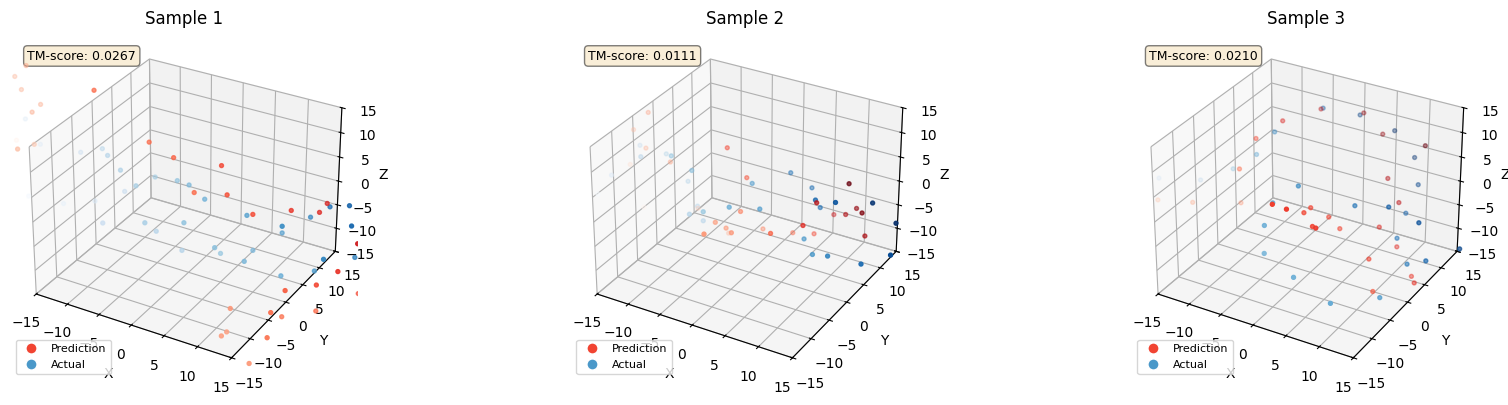

Epoch 267:
   - Avg train loss: 0.1087
   - Avg val loss: 0.2466
   - Est. avg val TM-score: 0.2274
   - Avg val invalidity score: 0.1588897384507163



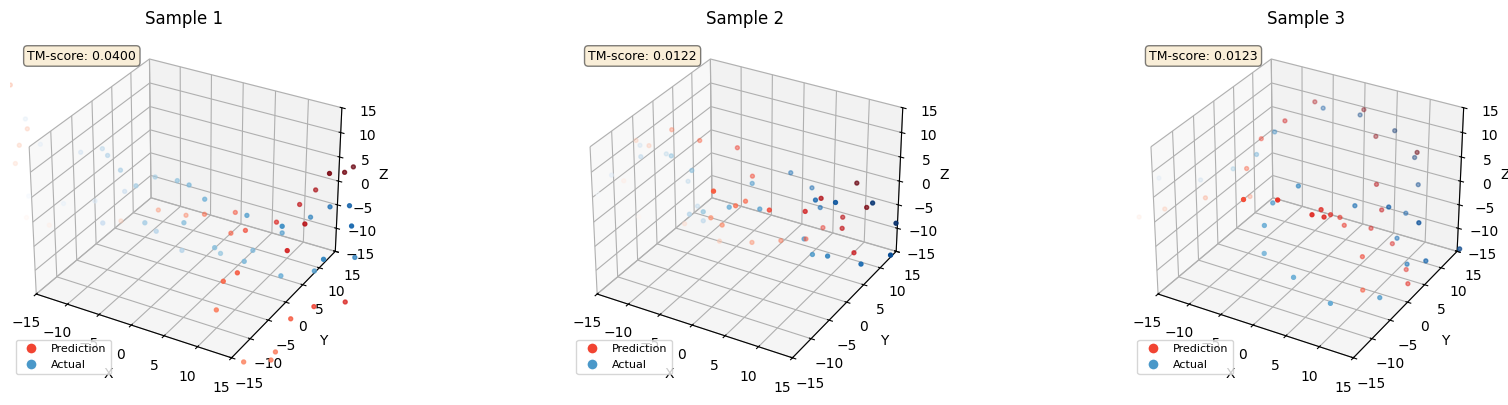

Epoch 268:
   - Avg train loss: 0.1072
   - Avg val loss: 0.2444
   - Est. avg val TM-score: 0.2198
   - Avg val invalidity score: 0.16028415259412462



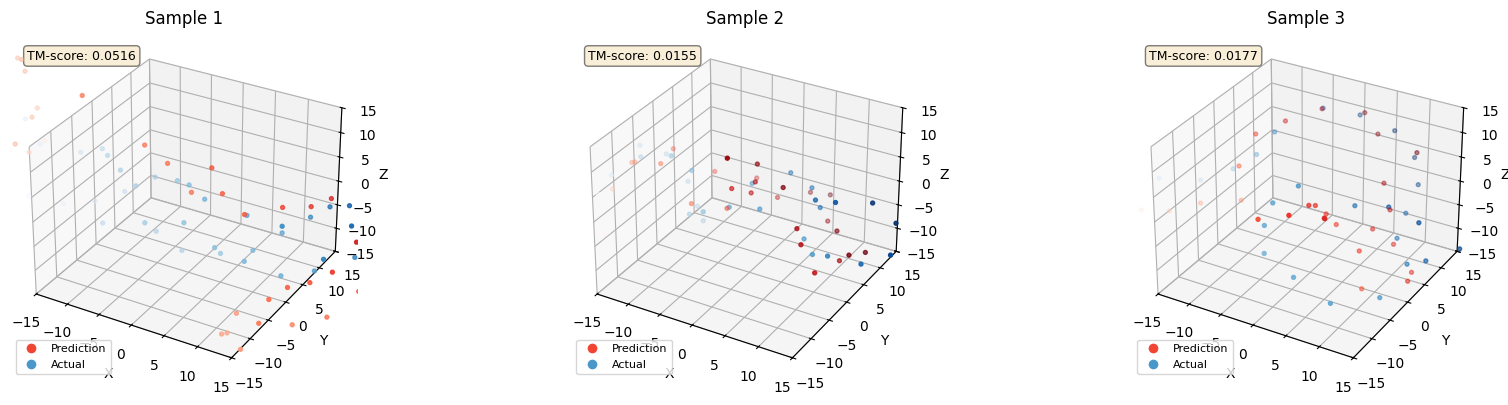

Epoch 269:
   - Avg train loss: 0.1063
   - Avg val loss: 0.2471
   - Est. avg val TM-score: 0.2228
   - Avg val invalidity score: 0.1587354934751731



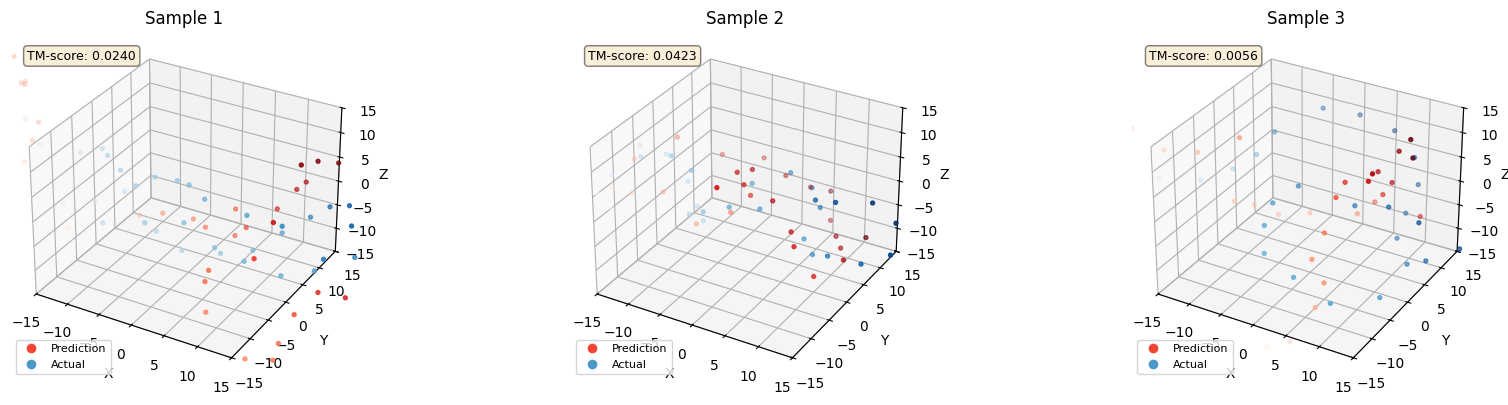

Epoch 270:
   - Avg train loss: 0.1054
   - Avg val loss: 0.2449
   - Est. avg val TM-score: 0.2229
   - Avg val invalidity score: 0.15851021151546552



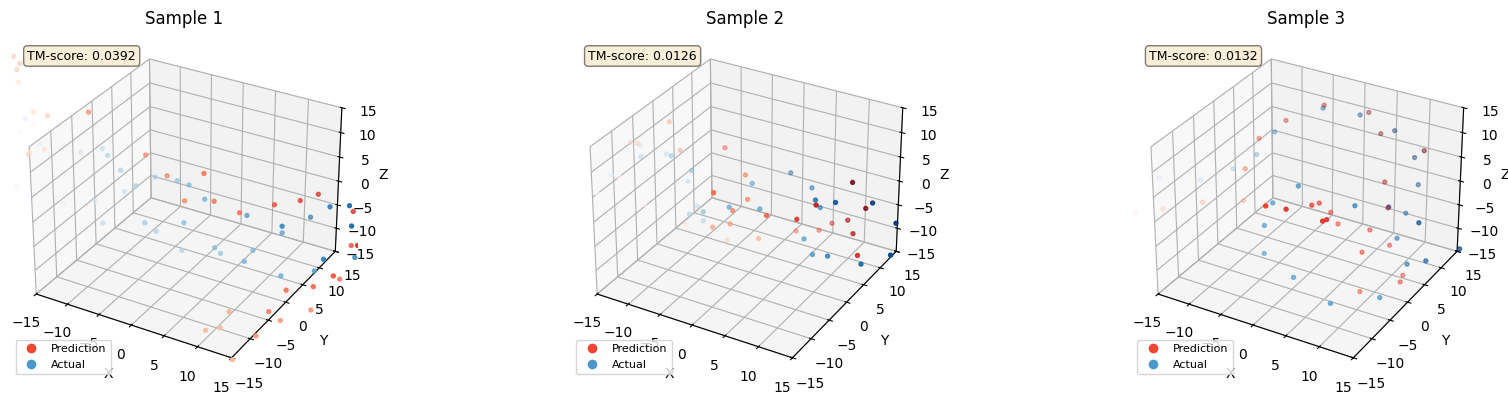

Epoch 271:
   - Avg train loss: 0.1046
   - Avg val loss: 0.2457
   - Est. avg val TM-score: 0.2308
   - Avg val invalidity score: 0.15967595251421807



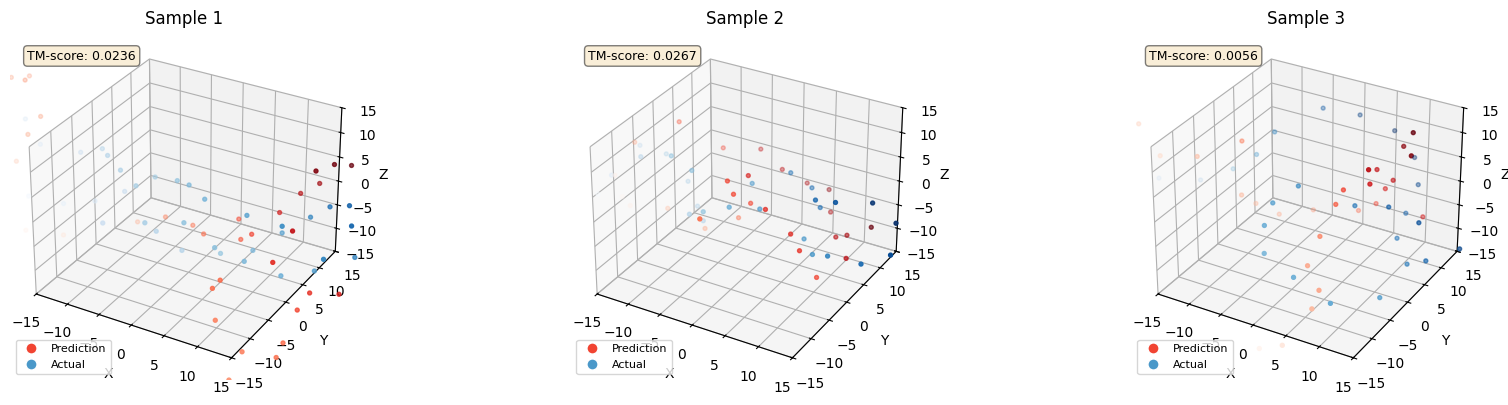

Epoch 272:
   - Avg train loss: 0.1036
   - Avg val loss: 0.2447
   - Est. avg val TM-score: 0.2240
   - Avg val invalidity score: 0.15939276957373213



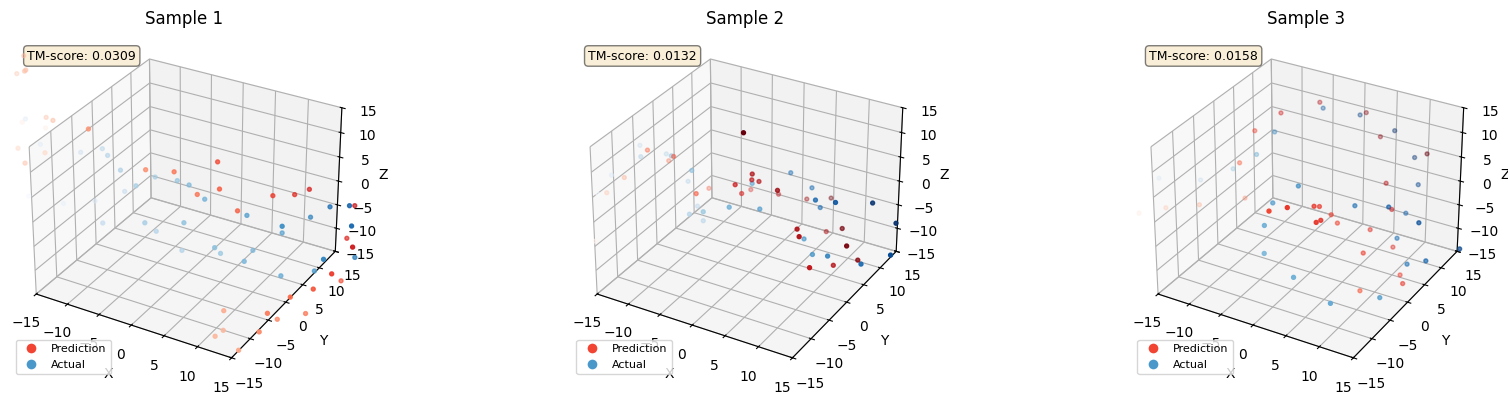

Epoch 273:
   - Avg train loss: 0.1032
   - Avg val loss: 0.2455
   - Est. avg val TM-score: 0.2200
   - Avg val invalidity score: 0.15942361992220933



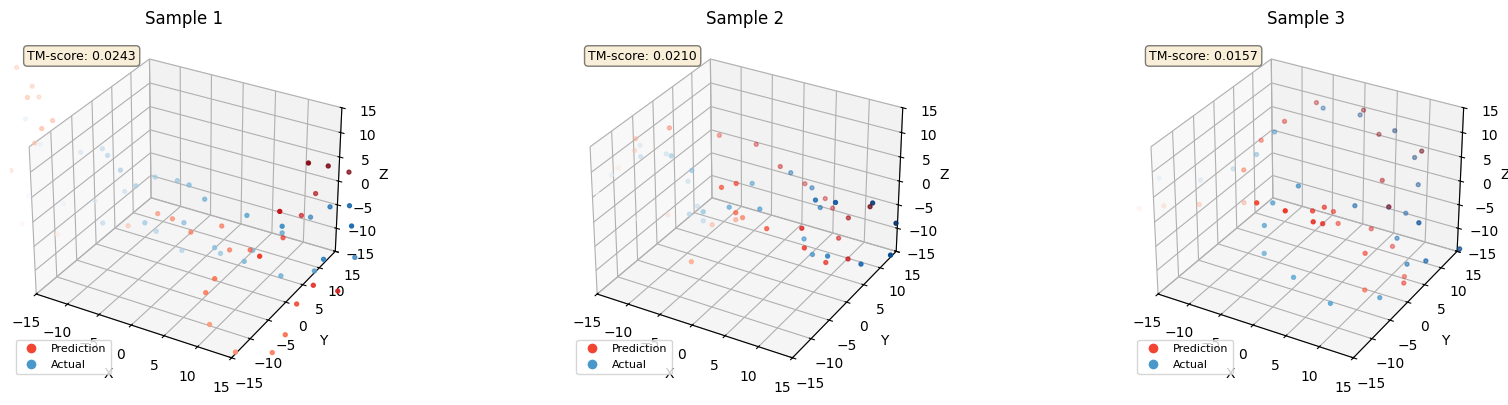

Epoch 274:
   - Avg train loss: 0.1022
   - Avg val loss: 0.2451
   - Est. avg val TM-score: 0.2213
   - Avg val invalidity score: 0.15894620325719577



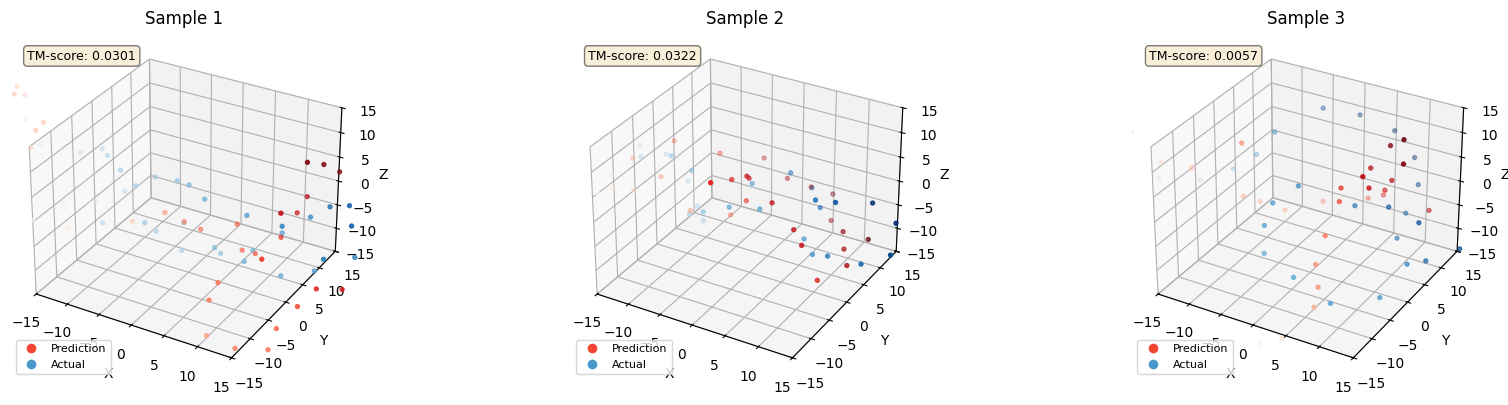

Epoch 275:
   - Avg train loss: 0.1011
   - Avg val loss: 0.2459
   - Est. avg val TM-score: 0.2142
   - Avg val invalidity score: 0.16136388437395868



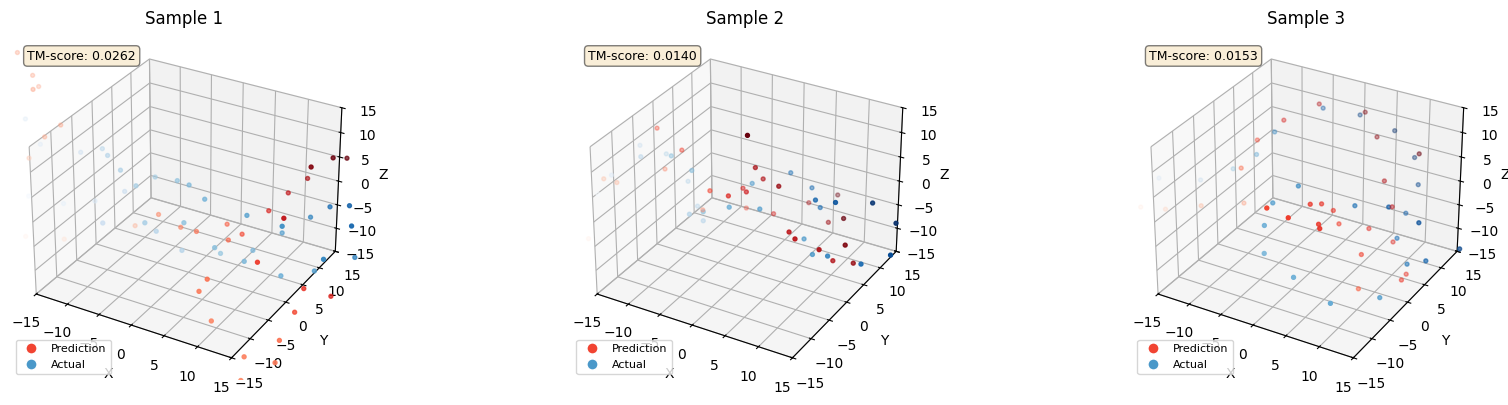

Epoch 276:
   - Avg train loss: 0.1004
   - Avg val loss: 0.2461
   - Est. avg val TM-score: 0.2307
   - Avg val invalidity score: 0.16023574944014432



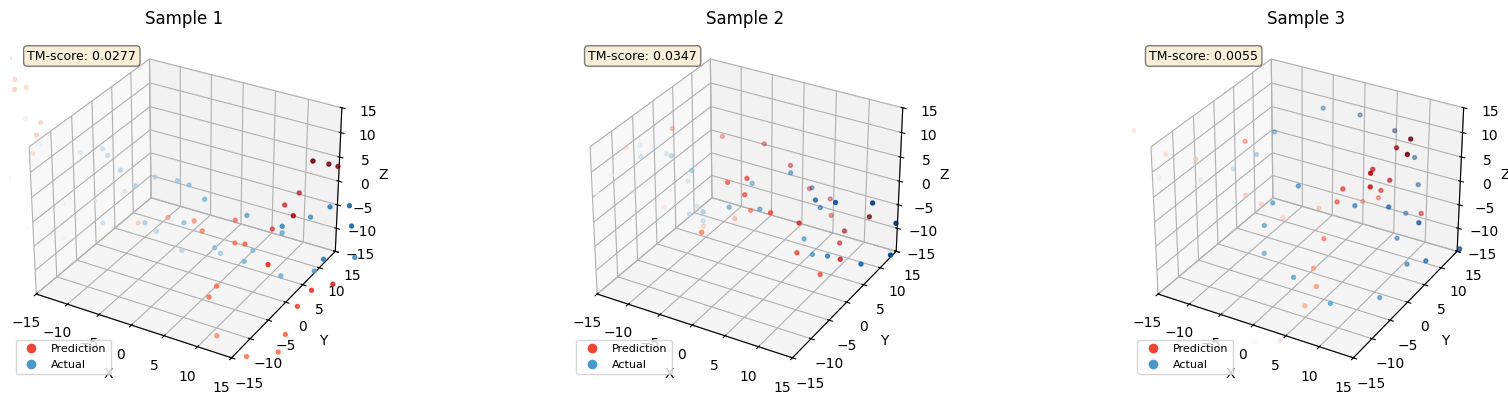

Epoch 277:
   - Avg train loss: 0.0998
   - Avg val loss: 0.2476
   - Est. avg val TM-score: 0.2354
   - Avg val invalidity score: 0.1612267830417131



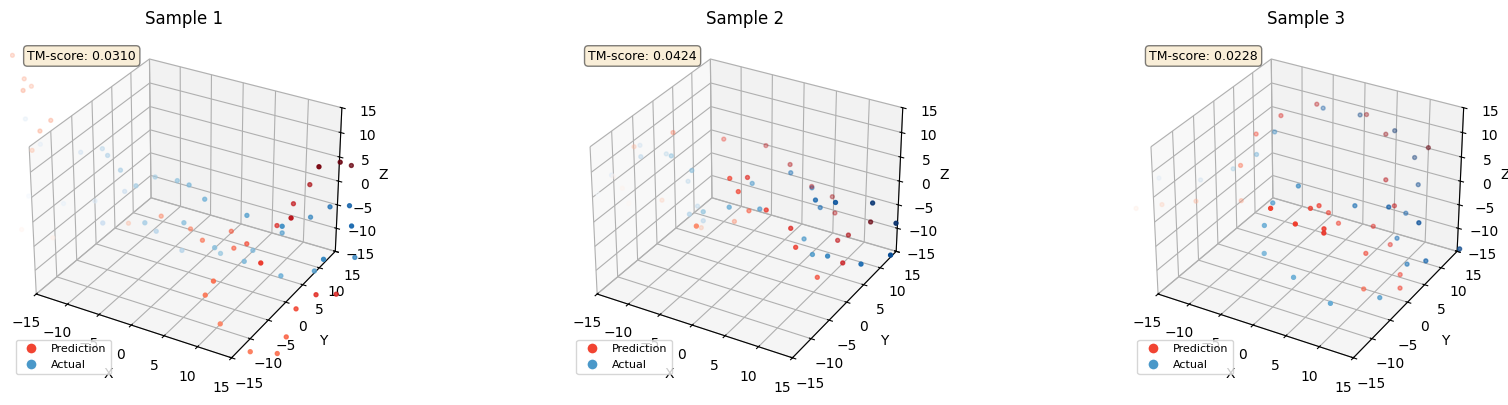

Epoch 278:
   - Avg train loss: 0.0990
   - Avg val loss: 0.2467
   - Est. avg val TM-score: 0.2292
   - Avg val invalidity score: 0.16050251137409666



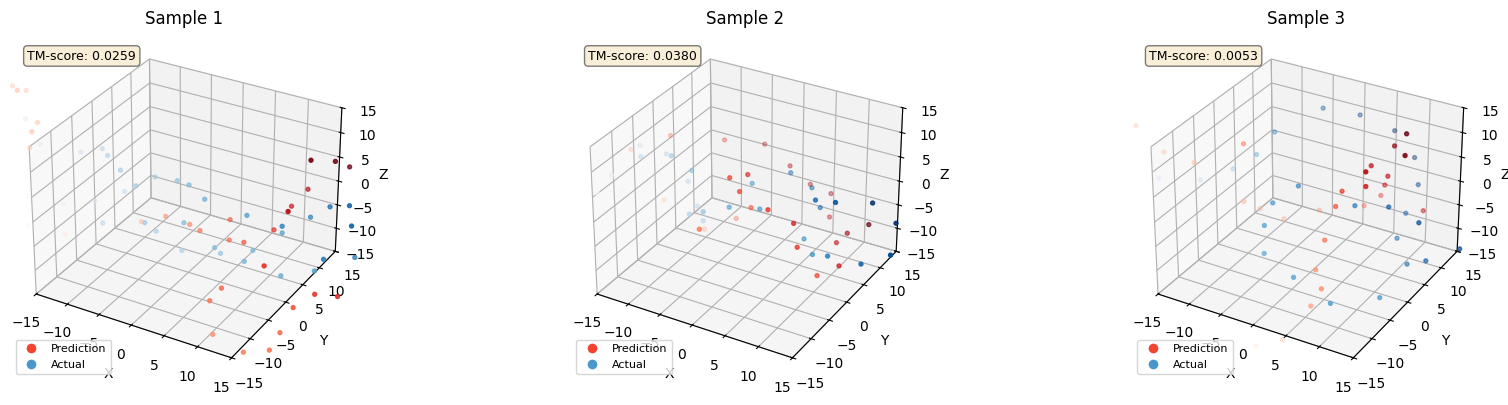

Epoch 279:
   - Avg train loss: 0.0982
   - Avg val loss: 0.2468
   - Est. avg val TM-score: 0.2207
   - Avg val invalidity score: 0.16015334302530326



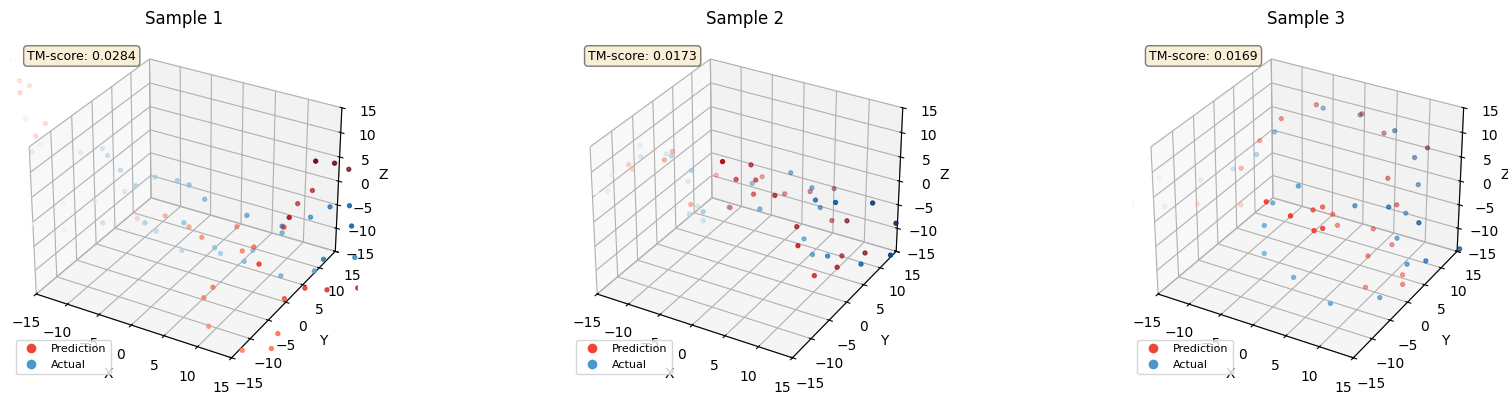

Epoch 280:
   - Avg train loss: 0.0972
   - Avg val loss: 0.2453
   - Est. avg val TM-score: 0.2271
   - Avg val invalidity score: 0.15835101005292726



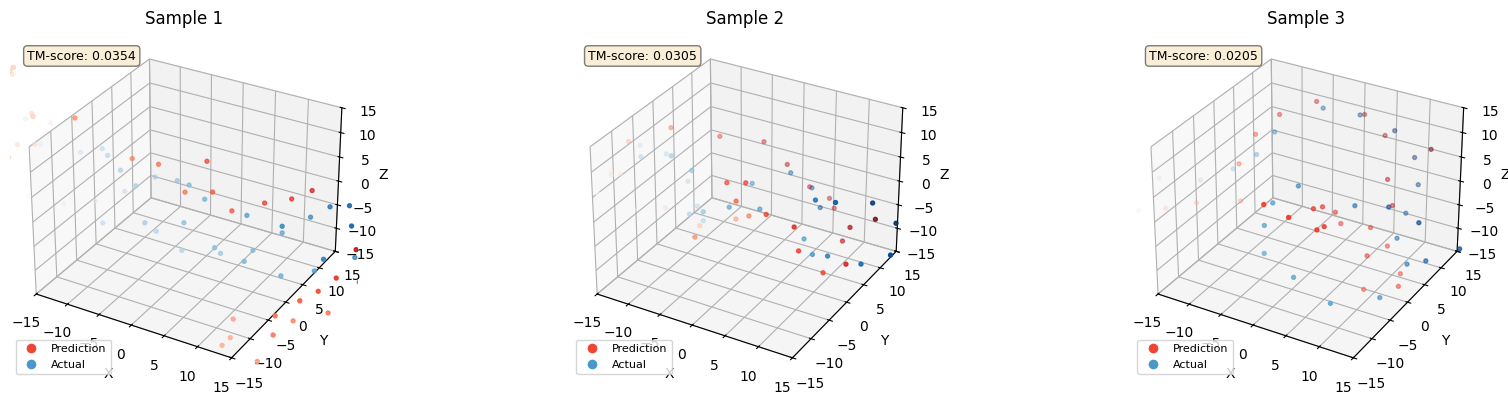

Epoch 281:
   - Avg train loss: 0.0967
   - Avg val loss: 0.2472
   - Est. avg val TM-score: 0.2224
   - Avg val invalidity score: 0.16120624065544228



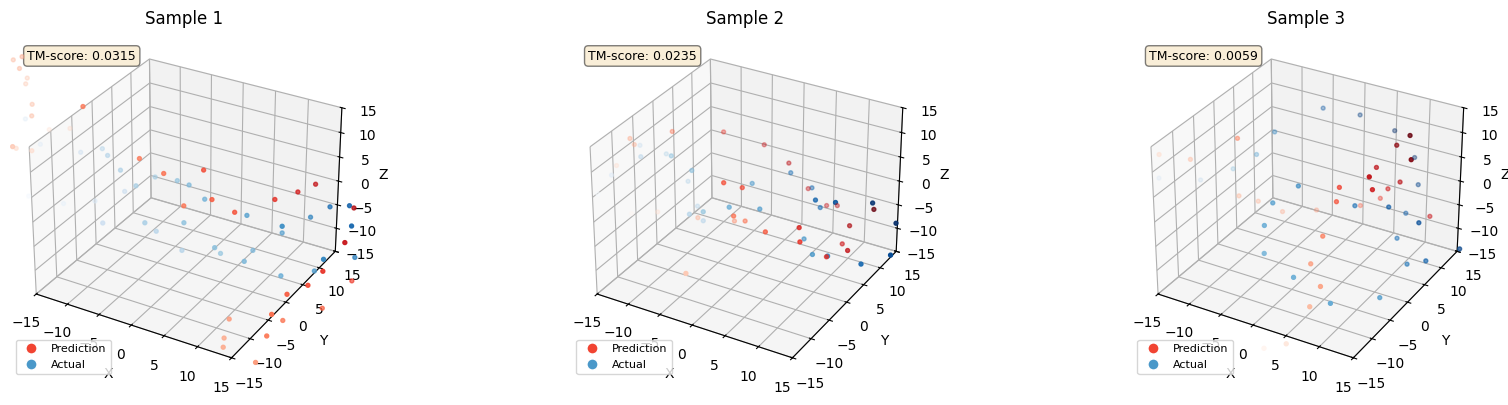

Epoch 282:
   - Avg train loss: 0.0961
   - Avg val loss: 0.2471
   - Est. avg val TM-score: 0.2275
   - Avg val invalidity score: 0.1612255744960239



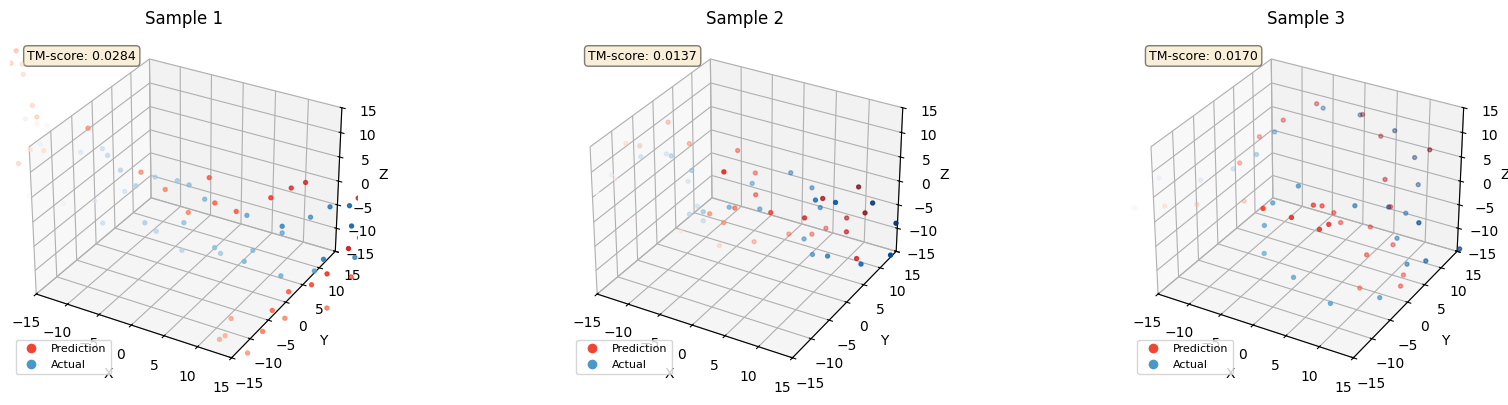

Epoch 283:
   - Avg train loss: 0.0955
   - Avg val loss: 0.2470
   - Est. avg val TM-score: 0.2233
   - Avg val invalidity score: 0.16213279029400204



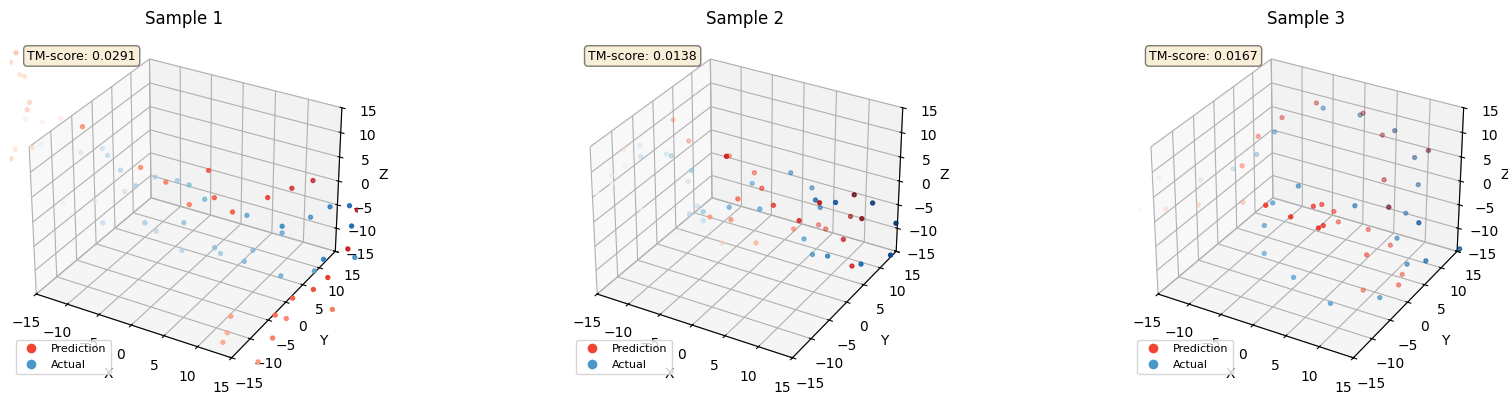

Epoch 284:
   - Avg train loss: 0.0947
   - Avg val loss: 0.2482
   - Est. avg val TM-score: 0.2287
   - Avg val invalidity score: 0.16054609646934814



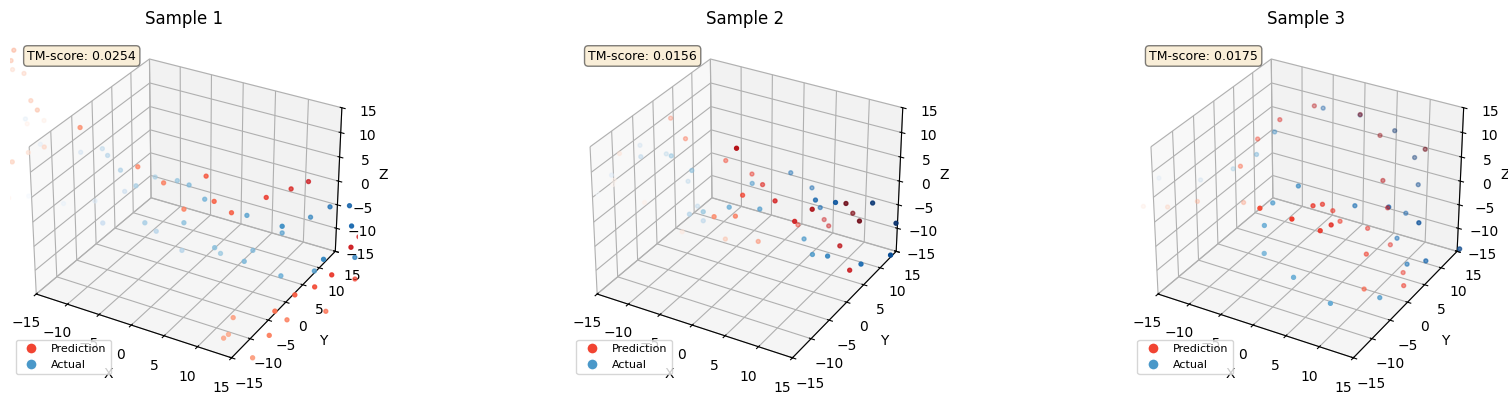

Epoch 285:
   - Avg train loss: 0.0939
   - Avg val loss: 0.2475
   - Est. avg val TM-score: 0.2271
   - Avg val invalidity score: 0.1609917907840313



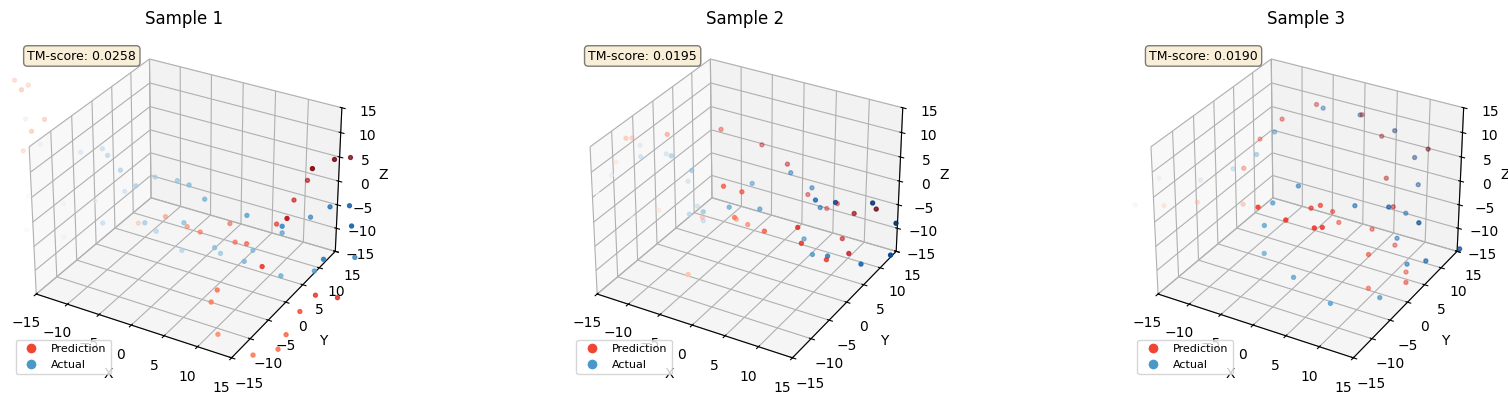

Epoch 286:
   - Avg train loss: 0.0935
   - Avg val loss: 0.2473
   - Est. avg val TM-score: 0.2272
   - Avg val invalidity score: 0.1613388159594891



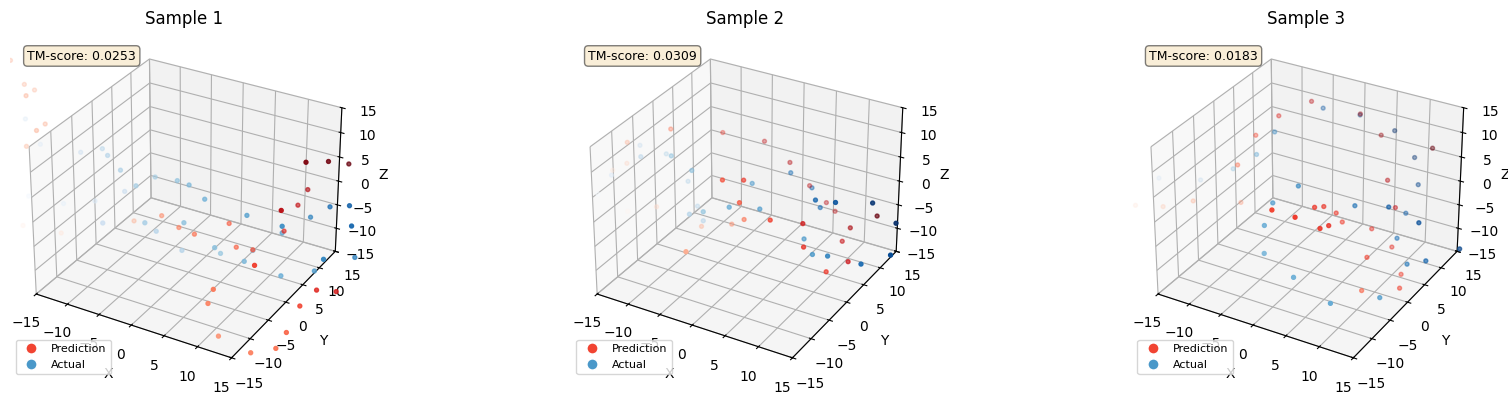

Epoch 287:
   - Avg train loss: 0.0932
   - Avg val loss: 0.2483
   - Est. avg val TM-score: 0.2259
   - Avg val invalidity score: 0.16140109448814885



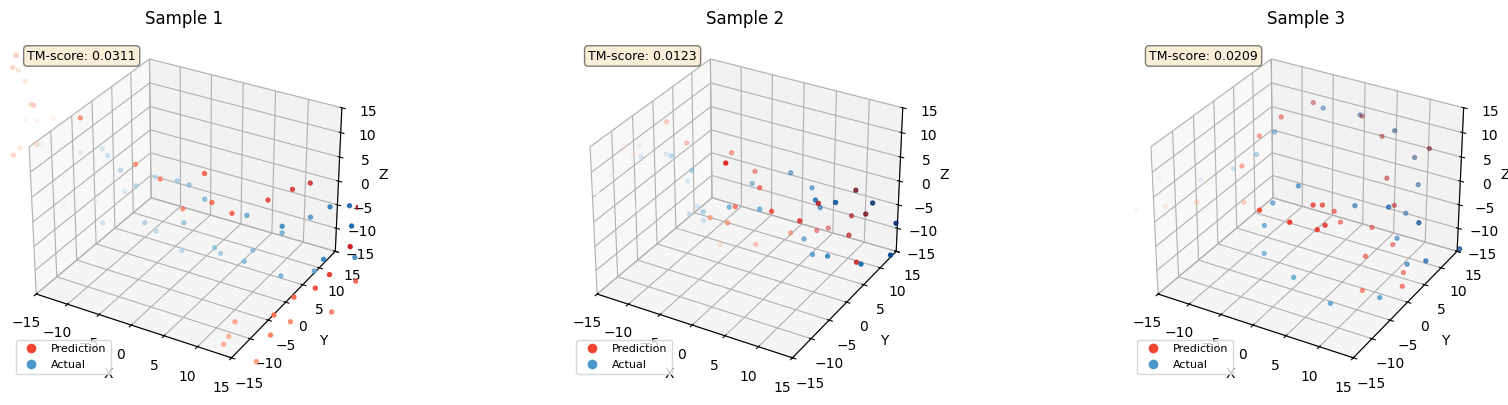

Epoch 288:
   - Avg train loss: 0.0924
   - Avg val loss: 0.2486
   - Est. avg val TM-score: 0.2292
   - Avg val invalidity score: 0.16188766217166314



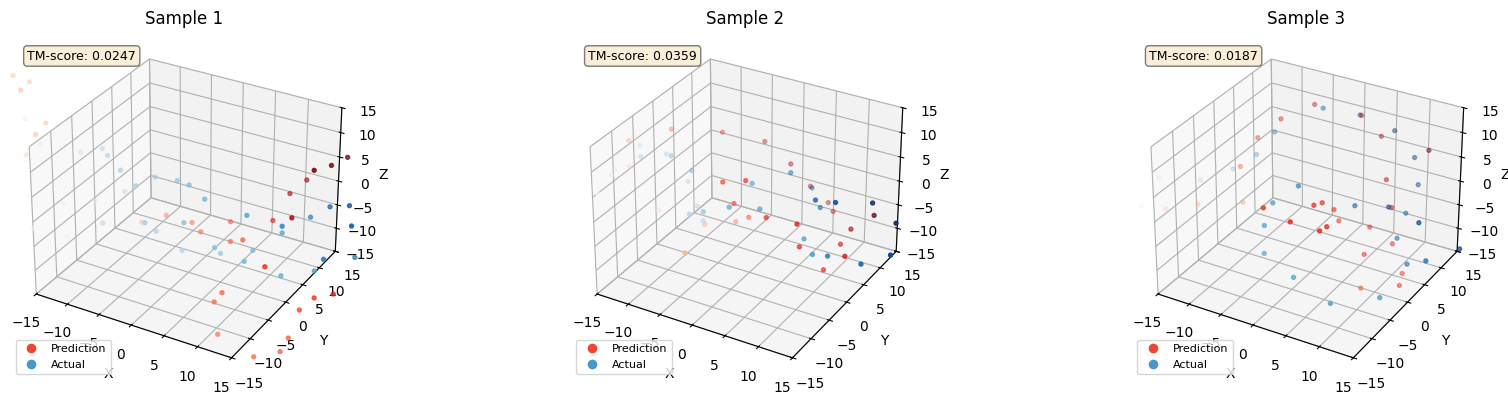

Epoch 289:
   - Avg train loss: 0.0917
   - Avg val loss: 0.2476
   - Est. avg val TM-score: 0.2313
   - Avg val invalidity score: 0.16292224911588998



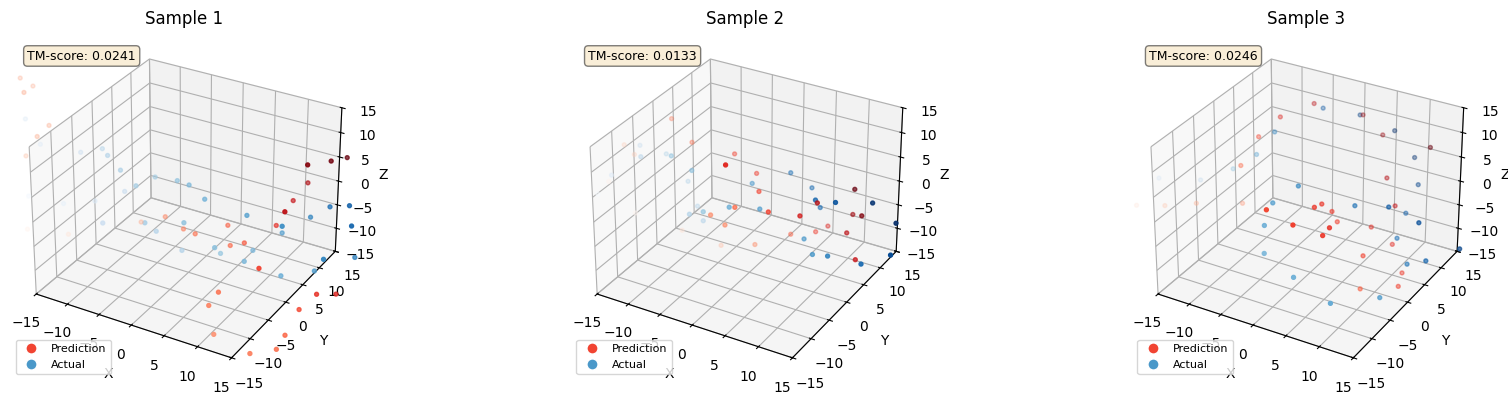

Epoch 290:
   - Avg train loss: 0.0914
   - Avg val loss: 0.2480
   - Est. avg val TM-score: 0.2399
   - Avg val invalidity score: 0.16205680212418674



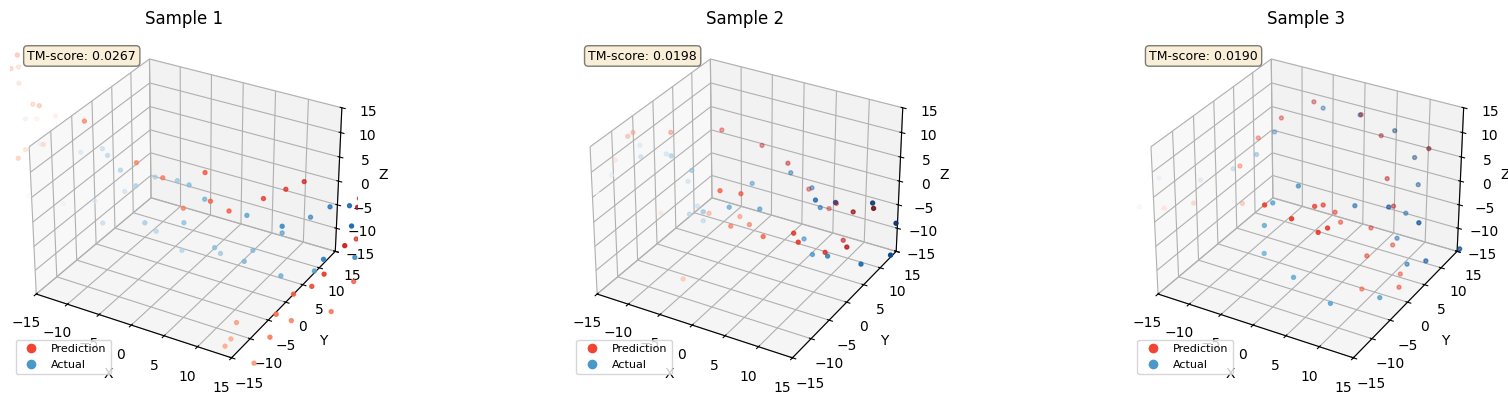

Epoch 291:
   - Avg train loss: 0.0908
   - Avg val loss: 0.2476
   - Est. avg val TM-score: 0.2344
   - Avg val invalidity score: 0.1616462585996775



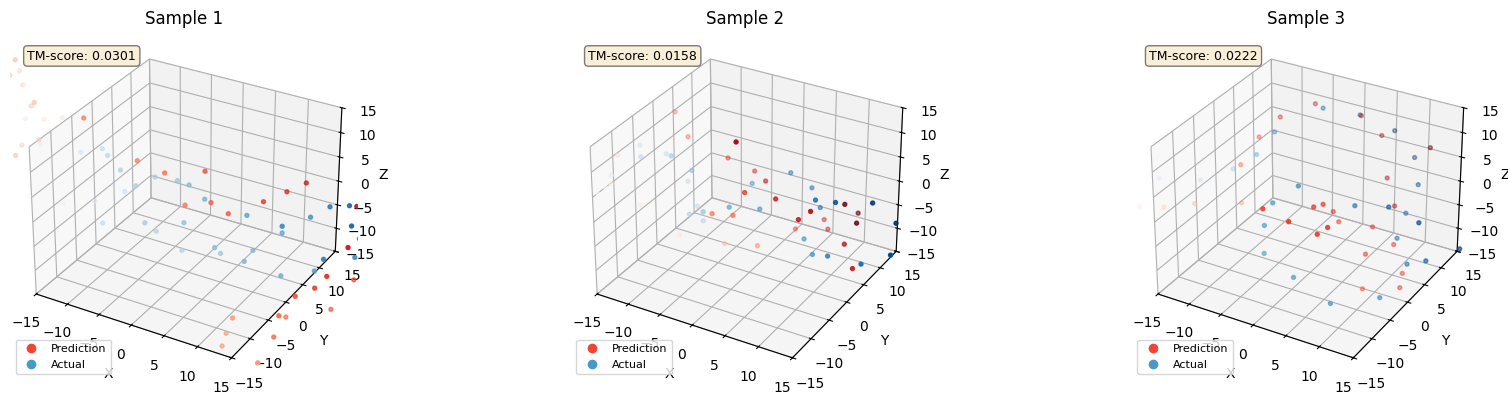

Epoch 292:
   - Avg train loss: 0.0904
   - Avg val loss: 0.2481
   - Est. avg val TM-score: 0.2407
   - Avg val invalidity score: 0.16157708455364408



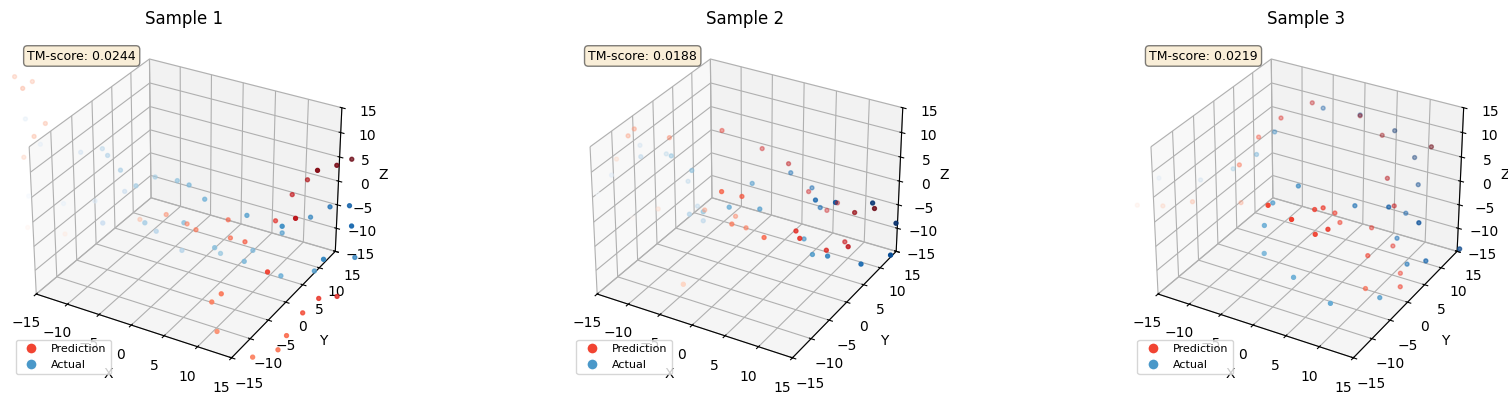

Epoch 293:
   - Avg train loss: 0.0901
   - Avg val loss: 0.2485
   - Est. avg val TM-score: 0.2282
   - Avg val invalidity score: 0.16211757007050068



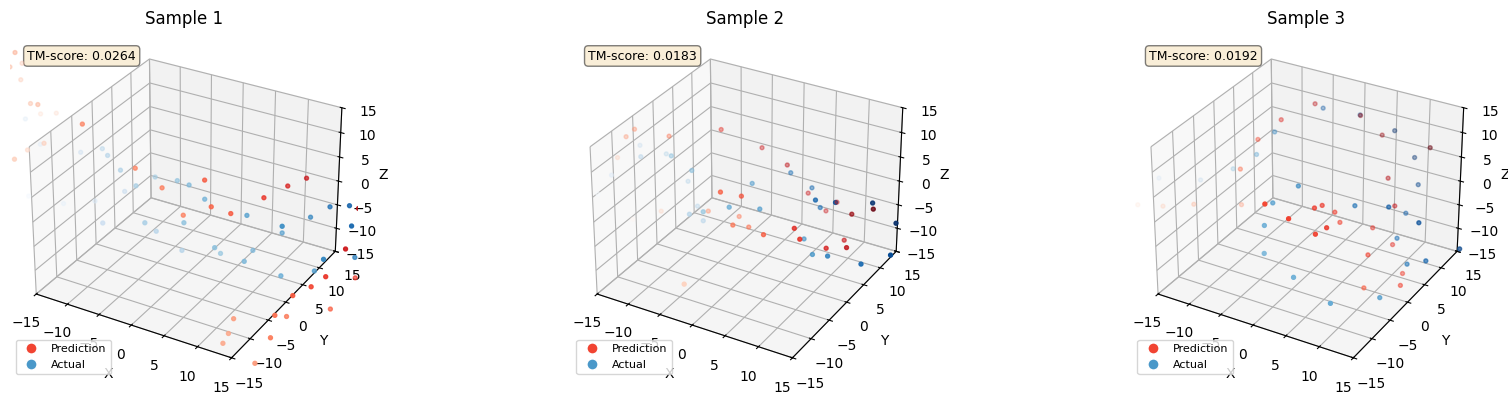

Epoch 294:
   - Avg train loss: 0.0897
   - Avg val loss: 0.2484
   - Est. avg val TM-score: 0.2302
   - Avg val invalidity score: 0.1611336205746647



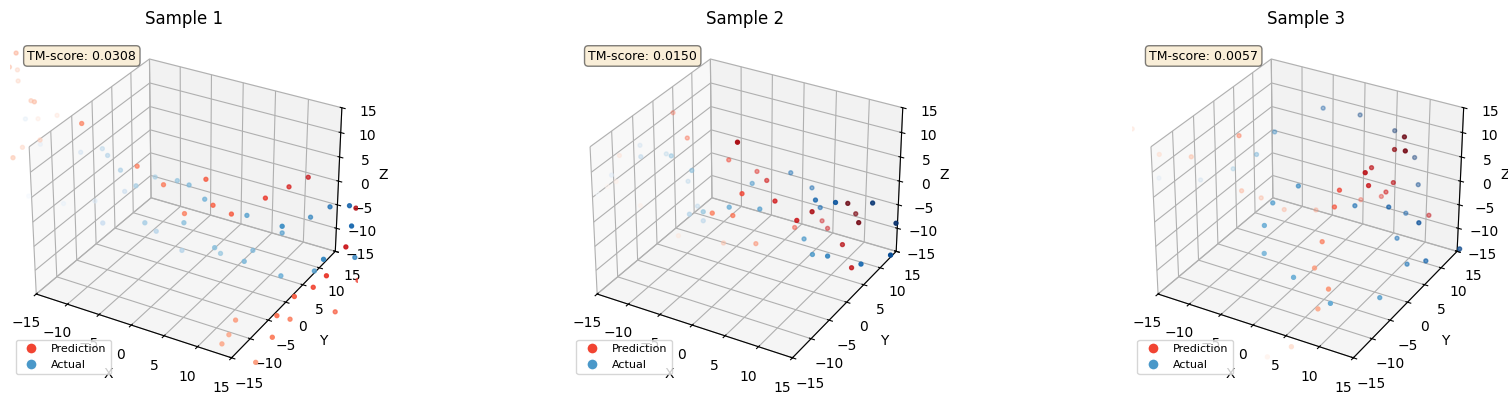

Epoch 295:
   - Avg train loss: 0.0890
   - Avg val loss: 0.2491
   - Est. avg val TM-score: 0.2339
   - Avg val invalidity score: 0.16267177210462475



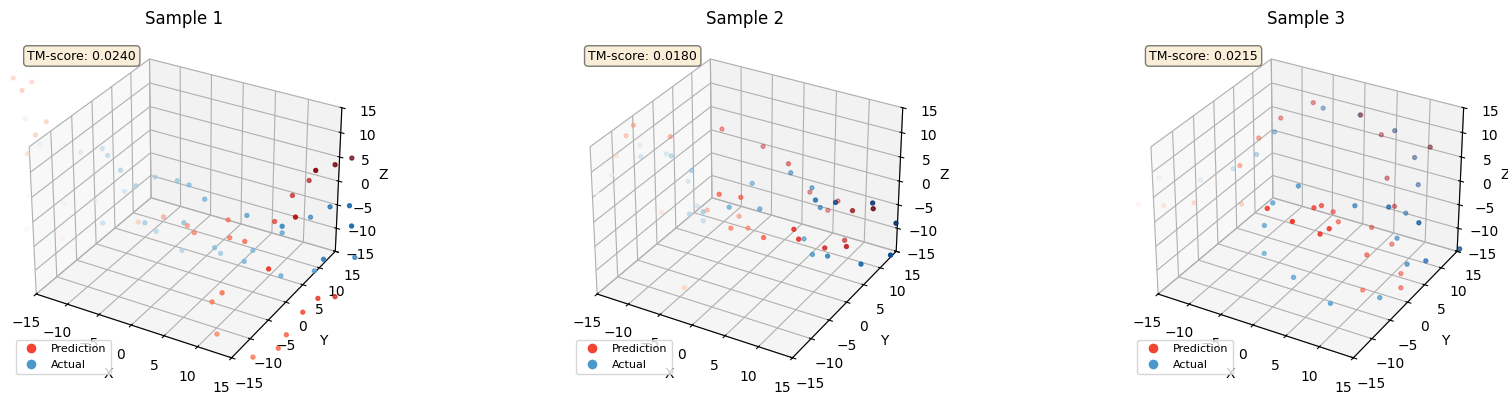

Epoch 296:
   - Avg train loss: 0.0890
   - Avg val loss: 0.2489
   - Est. avg val TM-score: 0.2303
   - Avg val invalidity score: 0.16266028501665467



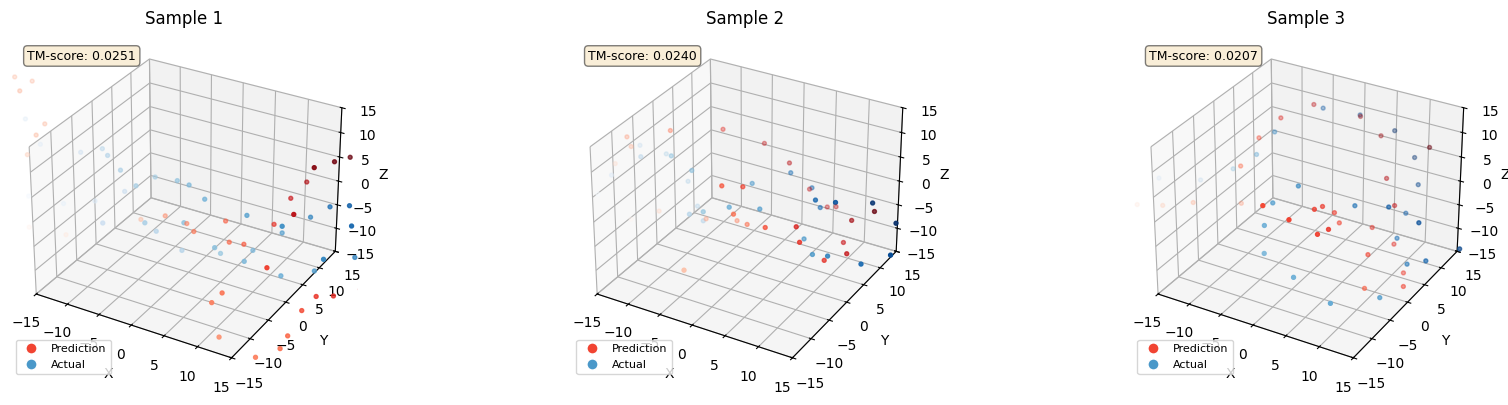

Epoch 297:
   - Avg train loss: 0.0886
   - Avg val loss: 0.2488
   - Est. avg val TM-score: 0.2340
   - Avg val invalidity score: 0.16213882394186757



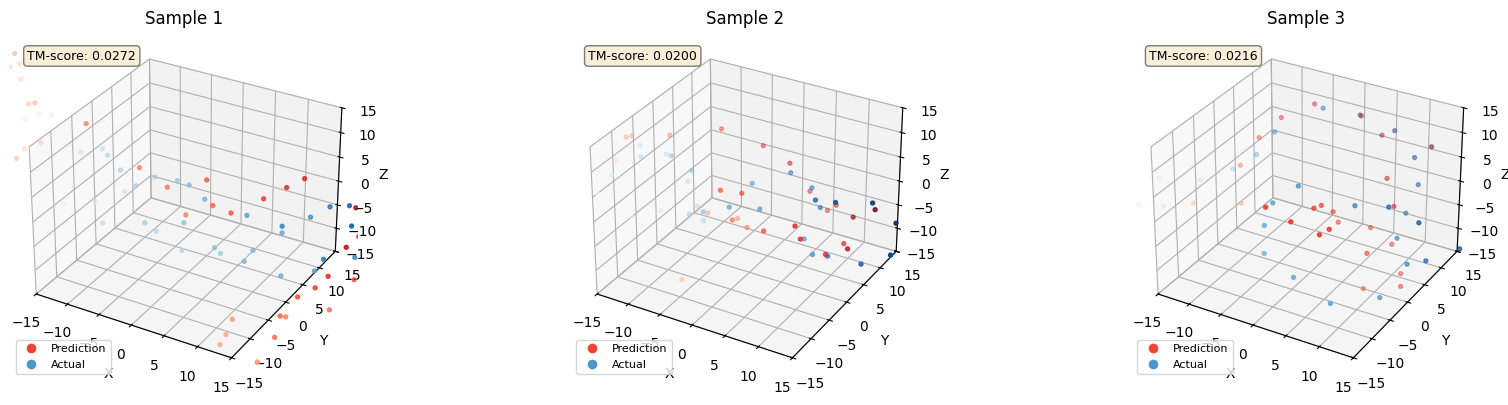

Epoch 298:
   - Avg train loss: 0.0887
   - Avg val loss: 0.2488
   - Est. avg val TM-score: 0.2384
   - Avg val invalidity score: 0.16280725758263173



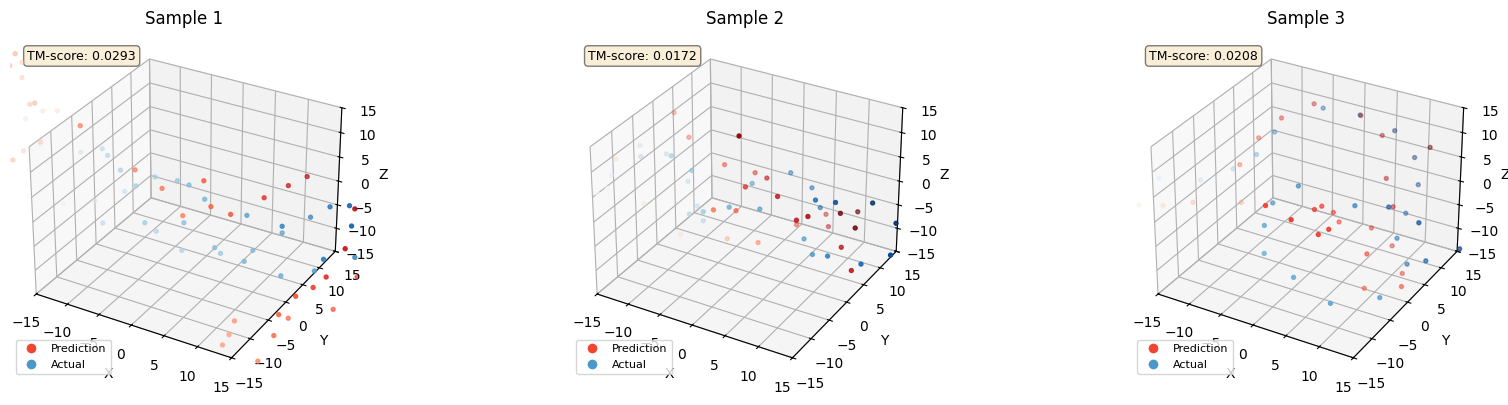

Epoch 299:
   - Avg train loss: 0.0881
   - Avg val loss: 0.2487
   - Est. avg val TM-score: 0.2348
   - Avg val invalidity score: 0.16293575198872698



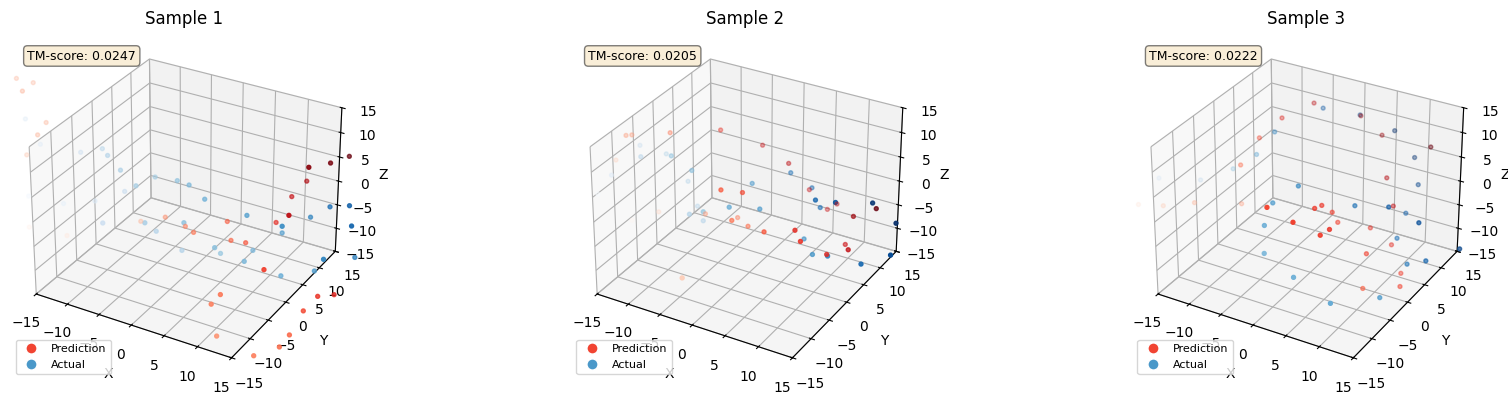

Epoch 300:
   - Avg train loss: 0.0881
   - Avg val loss: 0.2488
   - Est. avg val TM-score: 0.2384
   - Avg val invalidity score: 0.16252047334780356



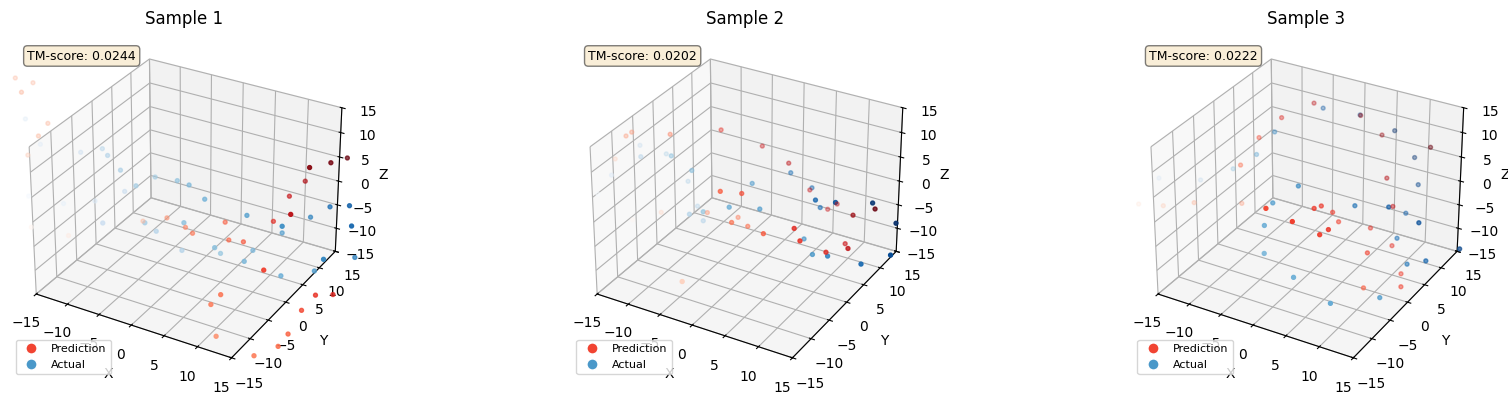

Epoch 301:
   - Avg train loss: 0.0878
   - Avg val loss: 0.2492
   - Est. avg val TM-score: 0.2382
   - Avg val invalidity score: 0.1625559582350526



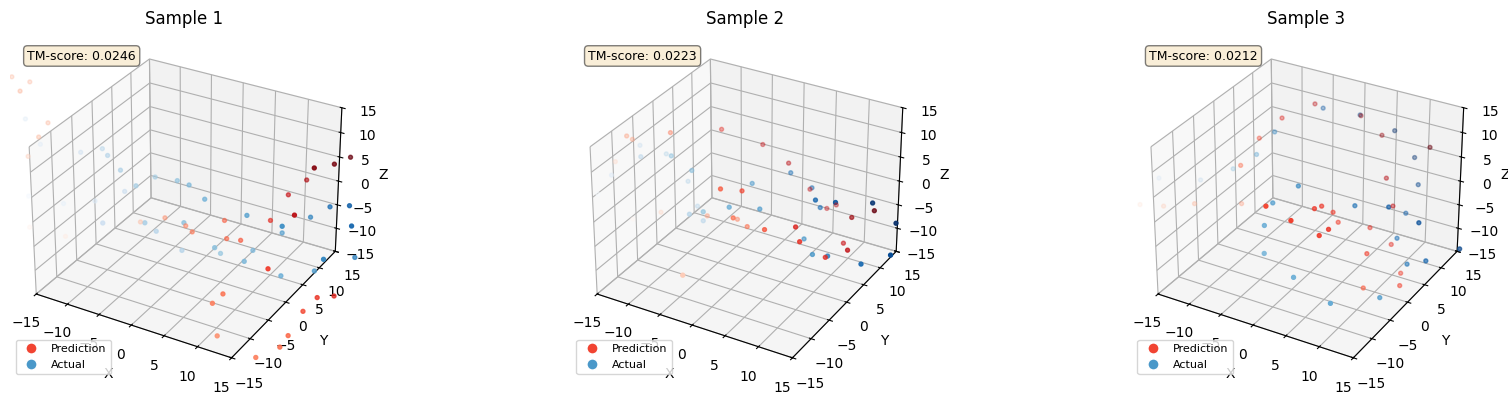

Epoch 302:
   - Avg train loss: 0.0878
   - Avg val loss: 0.2491
   - Est. avg val TM-score: 0.2314
   - Avg val invalidity score: 0.16247394299091092



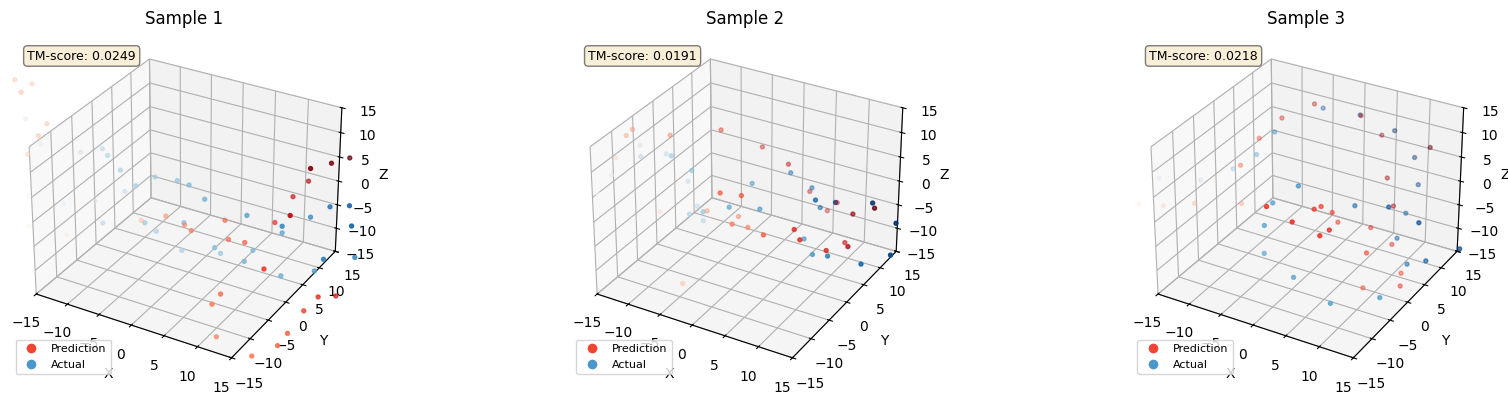

Epoch 303:
   - Avg train loss: 0.0878
   - Avg val loss: 0.2491
   - Est. avg val TM-score: 0.2347
   - Avg val invalidity score: 0.16281526321640322



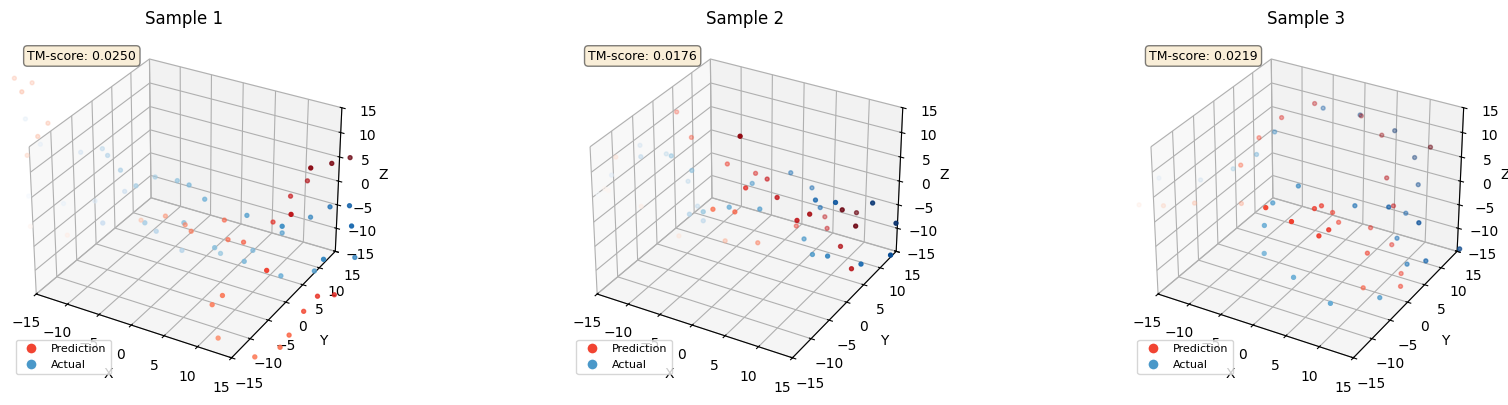

Epoch 304:
   - Avg train loss: 0.0874
   - Avg val loss: 0.2491
   - Est. avg val TM-score: 0.2291
   - Avg val invalidity score: 0.16285144464989254



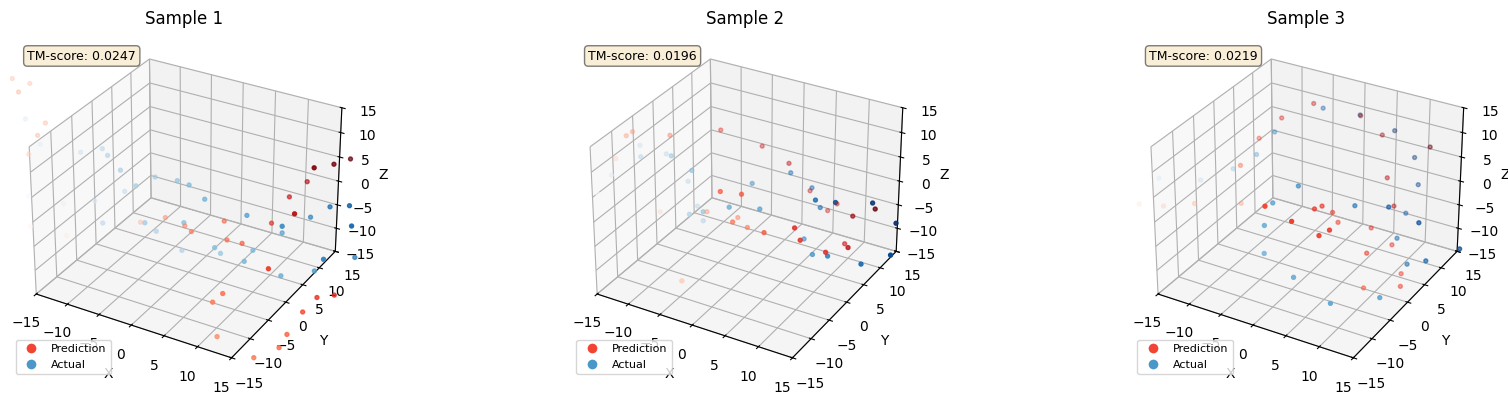

Epoch 305:
   - Avg train loss: 0.0874
   - Avg val loss: 0.2491
   - Est. avg val TM-score: 0.2320
   - Avg val invalidity score: 0.1625292378877887



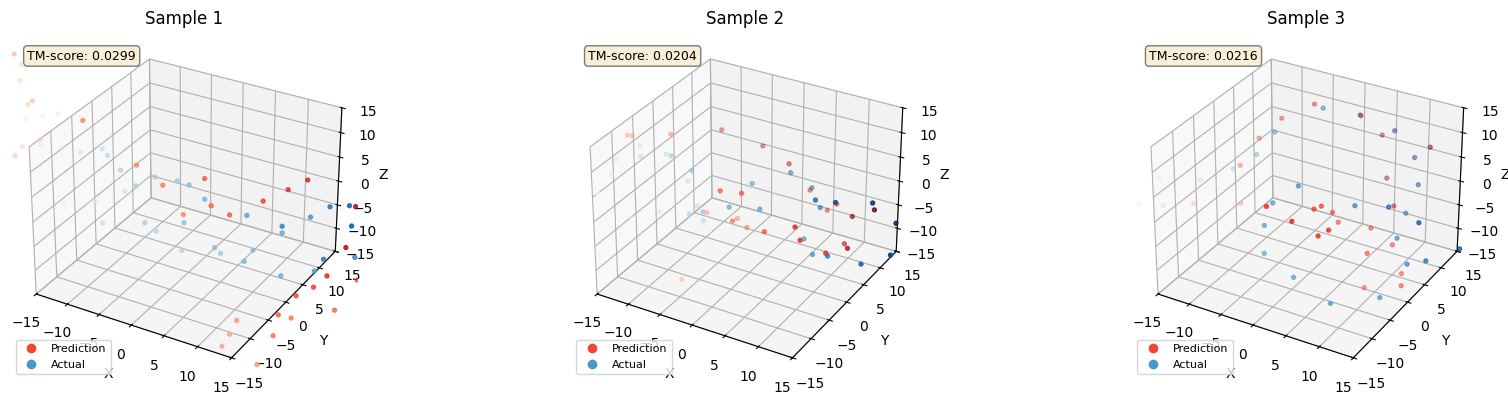

Epoch 306:
   - Avg train loss: 0.0872
   - Avg val loss: 0.2489
   - Est. avg val TM-score: 0.2390
   - Avg val invalidity score: 0.16254086005120671



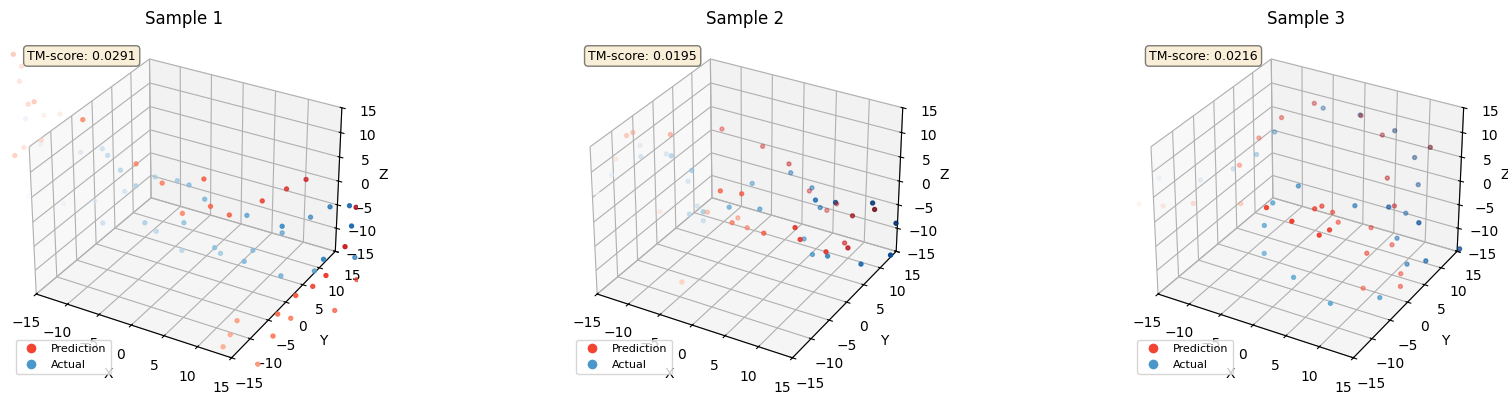

Epoch 307:
   - Avg train loss: 0.0873
   - Avg val loss: 0.2492
   - Est. avg val TM-score: 0.2343
   - Avg val invalidity score: 0.1628783924350125



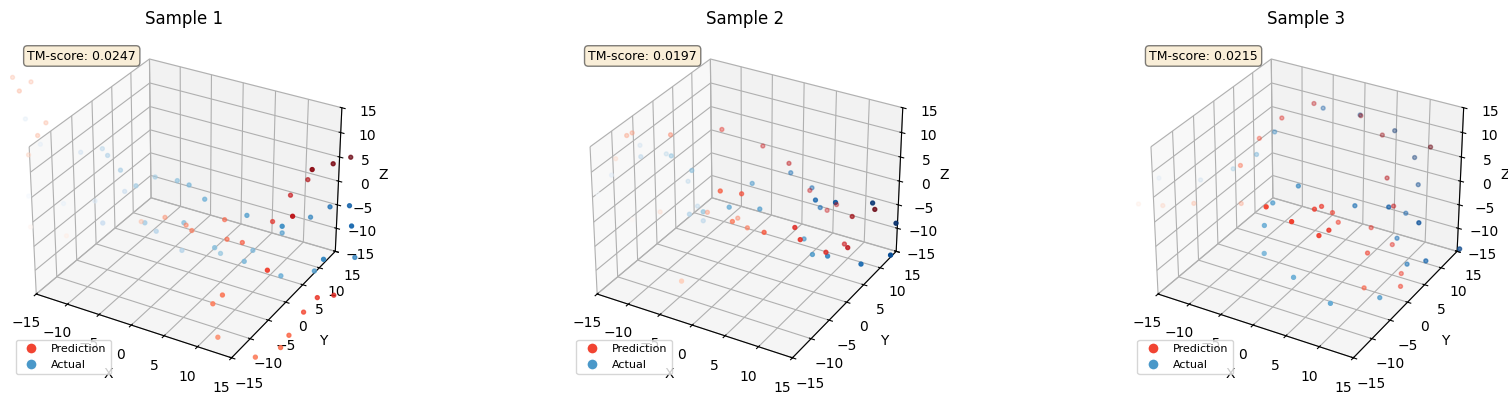

Epoch 308:
   - Avg train loss: 0.0872
   - Avg val loss: 0.2492
   - Est. avg val TM-score: 0.2383
   - Avg val invalidity score: 0.16291734481883122



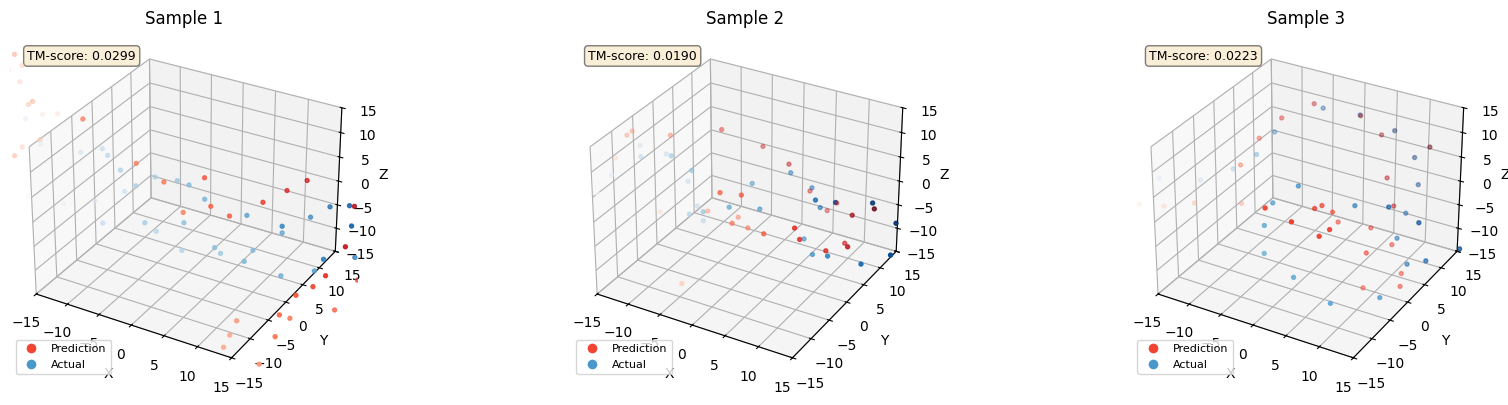

Stopping early due to: No more improvements


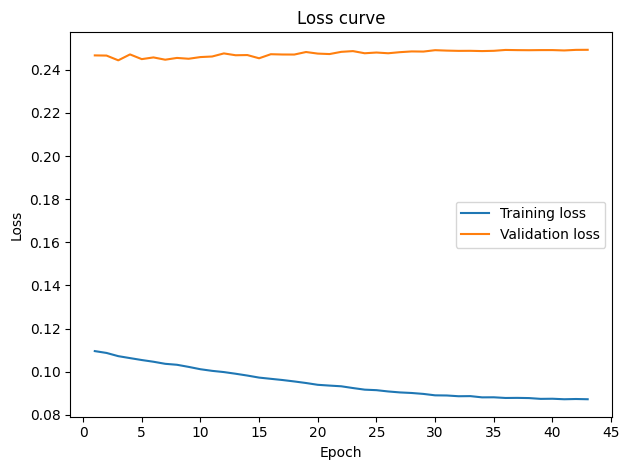

In [29]:
torch.manual_seed(42)
run_dir = create_run_dir(experiment_name)
metrics = {'training': [], 'validation': []}

scaler = torch.GradScaler('cuda')

for epoch in range(266, epochs + 1):
    metrics['training'].append(run_train_epoch(model, train_loader, loss_fn, optimizer, scaler))
    metrics['validation'].append(run_validation_epoch(model, val_loader, loss_fn))

    metrics['training'][-1]['learning_rate'] = optimizer.param_groups[0]['lr']
    scheduler.step()

    save_checkpoint(model, optimizer, scheduler, epoch, os.path.join(run_dir, 'checkpoint.pt'))
    display_save_metrics(run_dir, epoch, metrics)

    val_loss = metrics['validation'][-1]['loss_sum'] / metrics['validation'][-1]['sample_count']
    early_stopping(val_loss, model)
    
    if early_stopping.early_stop:
        print(f'Stopping early due to: {early_stopping.reason}')             
        break

save_loss_curve(run_dir, metrics)
torch.save(early_stopping.best_model_state, os.path.join(run_dir, 'best_model.pt'))